# Project n°3 : Vision Transformers vs. Convolutional Neural Networks

**Authors** : Selim Ben Abdallah¹, Paola De Truchis¹, Eduardo De Jesus Zancanaro Garcia¹, and Edda Iveland¹ \
¹ INSA Toulouse

The goal of this project is to compare the performance of vision transformers (ViTs) to convolutional neural networks (CNNs) on the task of image classification on labelled datasets.

---
---

**Our notebook is structured as follows :**

1. **Presentation of the datasets**
- CIFAR-10
- Food-101

2. **Convolution Neural Networks**
- Custom CNN
- ResNet-18

3. **Vision Transformers**
- Vision Transformers (Tiny)

4. **Comparison**
- CNN vs Vision Transformers
- Our results vs Literature
5. **Conclusion**


---
---

In [27]:
import importlib
import numpy as np
import matplotlib.pyplot as plt
from utils.utils_drive import download_gdrive_folder
from sklearn.metrics import confusion_matrix

import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset

import utils.utils_metrics_project_3 as ump3
import utils.utils_train_eval_project_3 as utep3
importlib.reload(ump3)
importlib.reload(utep3)
from utils.utils_metrics_project_3 import get_confusion_matrix, plot_history, plot_confusion_matrix, pick_indices, show_predictions_grid, top_confusions, show_predictions_grid_viz
from utils.utils_train_eval_project_3 import train_model, evaluate
from utils.utils_train_eval_project_3 import train_model_resnet

import models.models_project_3 as mp3
import models.models_project_3_vit as mp3v

importlib.reload(mp3)
importlib.reload(mp3v)

from models.models_project_3 import Custom_CNN, Custom_CNN_v2
from models.models_project_3 import ResNet18
from models.models_project_3_vit import ViTTiny

# Images
from IPython.display import Image, display

In [2]:
TRAIN_CNN_V1_CIFAR = False
TRAIN_CNN_V2_CIFAR = False
TRAIN_CNN_V2_FOOD = False

TRAIN_RESNET_CIFAR = False
TRAIN_RESNET_FOOD = False

TRAIN_VIT_CIFAR = False
TRAIN_VIT_FOOD = False

IMG_SIZE = 224

IMAGENET_MEAN = (0.485, 0.456, 0.406) # We are going to use same normalization for both datasets
IMAGENET_STD  = (0.229, 0.224, 0.225)

IMAGENET_MEAN_TENSOR = torch.tensor([0.485, 0.456, 0.406]) #used when plotting predictions
IMAGENET_STD_TENSOR  = torch.tensor([0.229, 0.224, 0.225])

In [3]:
# GDrive/Local paths to trained models

## CNN on CIFAR/FOOD
GDRIVE_PATH_TO_CNN_V1_CIFAR_30EP = "https://drive.google.com/drive/folders/1pYrSIe_KUytz0vsx1FLckBn284WWbQxt?usp=sharing"
GDRIVE_PATH_TO_CNN_V2_CIFAR_30EP = "https://drive.google.com/drive/folders/1E5z9nauWGNAe2UxLYiktyA7ReMsUSweP?usp=sharing"
GDRIVE_PATH_TO_CNN_V2_FOOD_30EP = "https://drive.google.com/drive/folders/1hf_PGYhbYH-raXtmsc15zJwu71V0_72U?usp=sharing"

## ResNet on CIFAR/FOOD
GDRIVE_PATH_TO_RESNET_CIFAR_30EP = "https://drive.google.com/drive/folders/1fK9fmnojlNBfYGbgJi5Bos09woZTOa9F?usp=sharing"
GDRIVE_PATH_TO_RESNET_FOOD_30EP = "https://drive.google.com/drive/folders/1Pqar38CX-WsX1lGm7rMAmqniBZy9XWMd?usp=sharing"

## ViT on CIFAR/FOOD
GDRIVE_PATH_TO_VIT_CIFAR_30EP = "https://drive.google.com/drive/folders/1-UPOFvkwWIMf2UvprmQUrCtorw03-FT7?usp=sharing"
GDRIVE_PATH_TO_VIT_FOOD_30EsP = "https://drive.google.com/drive/folders/1Dr6-xQt0COcEdufC5yKJXOrCqMRAod_L?usp=sharing"
GDRIVE_PATH_TO_VIT_FOOD_30EP_LRSCHEDULER = "https://drive.google.com/drive/folders/1Uqsb4mIbku3Rj2oeIa_WXznyMV7JnW0_?usp=sharing"
GDRIVE_PATH_TO_VIT_FOOD_30EP_LABELSMOOTH = "https://drive.google.com/drive/folders/1Uqsb4mIbku3Rj2oeIa_WXznyMV7JnW0_?usp=sharing"

In [4]:
## Comment below once the model weights are installed
# Note : complete download takes 50-60sec

## Weights for CNN/ResNet18 trainings 
#download_cnn_v1_cifar = download_gdrive_folder(GDRIVE_PATH_TO_CNN_V1_CIFAR_30EP, "weights/project_3/cnn_v1_cifar_30ep")
#download_cnn_v2_cifar = download_gdrive_folder(GDRIVE_PATH_TO_CNN_V2_CIFAR_30EP, "weights/project_3/cnn_v2_cifar_30ep")
#download_cnn_v2_food = download_gdrive_folder(GDRIVE_PATH_TO_CNN_V2_FOOD_30EP, "weights/project_3/cnn_v2_food_30ep")

#download_resnet_cifar = download_gdrive_folder(GDRIVE_PATH_TO_RESNET_CIFAR_30EP, "weights/project_3/cnn_resnet_cifar_30ep")
#download_resnet_food = download_gdrive_folder(GDRIVE_PATH_TO_RESNET_FOOD_30EP, "weights/project_3/cnn_resnet_food_30ep")

## Weights for VIT trainings
#download_vit_cifar = download_gdrive_folder(GDRIVE_PATH_TO_VIT_CIFAR_30EP,"weights/project_3/vit_tiny_cifar_30ep")
#download_vit_food = download_gdrive_folder(GDRIVE_PATH_TO_VIT_FOOD_30EP,"weights/project_3/vit_tiny_food_30ep")
#download_vit_food_lrscheduler = download_gdrive_folder(GDRIVE_PATH_TO_VIT_FOOD_30EP_LRSCHEDULER,"weights/project_3/vit_tiny_food_30ep_lrscheduler")
#download_vit_food_labelsmoothing = download_gdrive_folder(GDRIVE_PATH_TO_VIT_FOOD_30EP_LABELSMOOTH,"weights/project_3/vit_tiny_food_30ep_labelsmoothing")


---
---

## 1 - Datasets

### 1.1 - Datasets

**CIFAR-10**

The CIFAR-10 dataset contains 60000 labelled images of 10 classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship and truck. The images are coloured and of size 32x32. We will resize the images to 224x224 to feed to our CNNs and Vision Transformers. As the dataset is neither too big nor too small, we hope that differences in performance between CNNs and ViTs will not be due to the dataset scale, but rather the models themselves. (change comment)

We will we defining the ViT and CNN **from scratch**, so using a dataset that is easier to train from scratch is essential. If we were to use a dataset with larger images, pretrained weights would have yielded higher performance, making it harder to compare models from scratch. 

Each class in the CIFAR-10 dataset contains the **same number of images** and labels are clear and distinguished. Consequently, differences between CNNs and ViTs will not be due to class imbalances or noisy annotations. 

Additionally, CIFAR-10 has been **extensively studied**, aiding the comparison we will perform at the end of this project to the literature.

**Food-101**

The Food-101 dataset was developed at ETH Zurich. The documentation can be found here: [Food-101](https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/). It contains 101000 images of 101 food classes. Each food class is thus represented by 1000 images. 

The train-test split is 75%-25%. What differentiates it from the CIFAR-10 dataset is that it's a larger dataset with about 10 times as many classes. The image sizes are larger and varies up to 512 pixels side length. We will scale them to 224x244 as we did with the CIFAR-10 dataset. The dataset contains noise from intense colours and some mislabelling.

Similarly to the CIFAR-10 datasets, Food-101 is a well documented dataset in the literature. It is also directly available from from torchvision.datasets. 

We believe that Food-101 will be useful to compare with CIFAR-10 when it comes to the performance of CNNs and ViTs. 


#### 1.1.1 - Data preparation : CIFAR-10

In [5]:
# CIFAR-10 (resized to 224*224)
train_transform_cifar = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE,scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

test_transform_cifar = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

train_cifar = datasets.CIFAR10(
    root="./datasets/dataset_project_3/cifar10",
    train=True,
    download=False, # Note : Set to False if already downloaded                      
    transform=train_transform_cifar
)

test_cifar = datasets.CIFAR10(
    root="./datasets/dataset_project_3/cifar10",
    train=False,
    download=False,   # Set to False if already downloaded                     
    transform=test_transform_cifar
)

# We will train on 224x224 images, but we will visualize 32x32 images
viz_cifar_test = datasets.CIFAR10(
    root="./datasets/dataset_project_3/cifar10",
    train=False,
    download=True,
    transform=transforms.ToTensor() 
)

In [6]:
# CIFAR-10 checks
print("CIFAR-10 SANITY CHECKS ")
print("Train size:", len(train_cifar))
print("Test size :", len(test_cifar))

print("The classes of the CIFAR-10 dataset are:")
cifar_class_names = train_cifar.classes
print(cifar_class_names)
print("---------------------")
print("There are", len(cifar_class_names), "classes")

x, y = train_cifar[0]
print("One sample:")
print("Image shape:", x.shape)   # should be torch.Size([3, 224, 224])
print("Label index:", y, "| class name:", cifar_class_names[y])

CIFAR-10 SANITY CHECKS 
Train size: 50000
Test size : 10000
The classes of the CIFAR-10 dataset are:
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
---------------------
There are 10 classes
One sample:
Image shape: torch.Size([3, 224, 224])
Label index: 6 | class name: frog


#### 1.1.2 - Data preparation : FOOD-101

In [7]:
## Note (bug on macs ...) : run once if code belows fails to downlaod the dataset

# _ = datasets.Food101(root="./datasets/dataset_project_3/food101", split="train", download=True)
# _ = datasets.Food101(root="./datasets/dataset_project_3/food101", split="test",  download=True)
# print("Food101 downloaded (or already present).")

In [8]:
# Food-101
train_transform_food = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE,scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN,IMAGENET_STD)
])

test_transform_food = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

train_food = datasets.Food101(
    root="./datasets/dataset_project_3/food101", #once downloaded keep this root and keep and switch to 'False'
    split="train",
    download=False,                      
    transform=train_transform_food
)

test_food = datasets.Food101(
    root="./datasets/dataset_project_3/food101",
    split="test",
    download=False,                      
    transform=test_transform_food
)

In [9]:
# Food-101 checks

print("FOOD-101 SANITY CHECKS")
print("Train size:", len(train_food))
print("Test size :", len(test_food))

print("The classes of the Food-101 dataset are:")
food_class_names = train_food.classes
print(food_class_names[:10], "...") # first 10 (there are 101 classes)
print("---------------------")
print("There are", len(food_class_names), "classes")

x, y = train_food[0]
print("\nOne sample:")
print("Image shape:", x.shape)   # should be torch.Size([3, 224, 224])
print("Label index:", y, "| class name:", food_class_names[y])

FOOD-101 SANITY CHECKS
Train size: 75750
Test size : 25250
The classes of the Food-101 dataset are:
['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito'] ...
---------------------
There are 101 classes

One sample:
Image shape: torch.Size([3, 224, 224])
Label index: 23 | class name: churros


#### 1.1.3 - Train / Val / Test Split : CIFAR-10

- CIFAR-10 contains 60,000 images, originally splitted in two sets : 50,000 images in a train set, and 10,000 images in a test set.
- We splitted the original train set into two subsets : train (80% of the initial train set) and validation (20% of the initial test set)
- This results in the following splitting : 
- Train : 40,000 images (66.67%) ; Val : 10,000 images (16.67%) ; Test : 10,000 images (16.67%)

In [10]:
# CIFAR-10 (creation of the validation split)
SEED = 42
VAL_FRACTION = 0.2   # train_cifar is splitted this way : 80% train & 20% validation

cifar_train_eval = datasets.CIFAR10(
    root="./datasets/dataset_project_3/cifar10",
    train=True,
    download=False,
    transform=test_transform_cifar, #no augmentations
)

n_total = len(train_cifar)
n_val = int(round(n_total * VAL_FRACTION))
n_train = n_total - n_val

g = torch.Generator().manual_seed(SEED) # number generator (randomness for random_split)

train_cifar_split, val_tmp = random_split(train_cifar, [n_train, n_val], generator=g)
val_cifar_split = Subset(cifar_train_eval, val_tmp.indices) # here we take the same validation images selecte by random_split(), but we load them from a dataset object that uses eval transforms
test_cifar_split = test_cifar #just renaming 

print(
    f"CIFAR sizes -> train: {len(train_cifar_split)} ({len(train_cifar_split)/600:.2f}%) "
    f"val: {len(val_cifar_split)} ({len(val_cifar_split)/600:.2f}%) "
    f"test: {len(test_cifar_split)} ({len(test_cifar_split)/600:.2f}%)"
)

CIFAR sizes -> train: 40000 (66.67%) val: 10000 (16.67%) test: 10000 (16.67%)


#### 1.1.4 - Train / Val / Test Split : FOOD-101

- FOOD-101 contains 101,000 images, originally splitted in two sets : 75,750 images in a train set, and 25,250 images in a test set.
- We splitted the original train set into two subsets : train (80% of the initial train set) and validation (20% of the initial test set)
- This results in the following splitting : 
- Train : 60,000 images (60%) ; Val : 15,150 images (15%) ; Test : 25,250 images (25%)

In [11]:
# Food-101 (creation of the validation split)

SEED = 42
VAL_FRACTION = 0.2  # 20% validation

food_train_eval = datasets.Food101(
    root="./datasets/dataset_project_3/food101",
    split="train",
    download=False,
    transform=test_transform_food,
)

n_total = len(train_food)
n_val = int(round(n_total * VAL_FRACTION))
n_train = n_total - n_val

g = torch.Generator().manual_seed(SEED)

train_food_split, val_tmp = random_split(train_food, [n_train, n_val], generator=g)
val_food_split = Subset(food_train_eval, val_tmp.indices)
test_food_split = test_food #just renaming 

print("Food sizes -> train:", len(train_food_split),"(",len(train_food_split)/1010,"%)", "val:", len(val_food_split),"(",len(val_food_split)/1010,"%)", "test:", len(test_food_split),"(",len(test_food_split)/1010,"%)", )

Food sizes -> train: 60600 ( 60.0 %) val: 15150 ( 15.0 %) test: 25250 ( 25.0 %)


#### 1.1.5 - DataLoaders

In [12]:
BATCH_SIZE = 32
NUM_WORKERS = 0

cifar_loaders = {
    "train": DataLoader(train_cifar_split, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, drop_last=True),
    "val":   DataLoader(val_cifar_split,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS),
    "test":  DataLoader(test_cifar,        batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS),
}

food_loaders = {
    "train": DataLoader(train_food_split, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, drop_last=True),
    "val":   DataLoader(val_food_split,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS),
    "test":  DataLoader(test_food,        batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS),
}

# quick check
xb, yb = next(iter(cifar_loaders["train"]))
print("CIFAR batch:", xb.shape, yb.shape)

xb, yb = next(iter(food_loaders["train"]))
print("Food batch:", xb.shape, yb.shape)

CIFAR batch: torch.Size([32, 3, 224, 224]) torch.Size([32])
Food batch: torch.Size([32, 3, 224, 224]) torch.Size([32])


## 2 - Convolutional Neural Networks



We begin by performing **multiclass image classification** using convolutional neural networks (CNNs). This approach builds on our work in *Project 1*, where we classified cat and dog breeds from images. In this project, we will implement two CNNs from scratch and recreated the ResNet architecture.



We designed and evaluated three different CNN architectures:



- **Custom_CNN** is a relatively simple model consisting of three convolutional layers with an increasing number of filters (32–64–128).



- **Custom_CNN_v2** is a deeper and more complext variant, adding an additional convolutional layer (32–64–128–256). Batch normalization and ReLU activation are applied after each convolutional layer to improve numerical stability during training.



- **ResNet-18** is a well-known, high-performance architecture used as a benchmark against our custom models. ResNet introduces residual connections that allow gradients to flow more effectively during training, mitigating the vanishing gradient problem ([source](https://medium.com/@datascientist_SheezaShabbir/a-comparative-study-on-vision-transformers-vs-resnet-in-multi-class-classification-544d9b665365)). We used an 18-layer variant, implemented following the code provided by [GeeksforGeeks](https://www.geeksforgeeks.org/deep-learning/resnet18-from-scratch-using-pytorch/).



We first trained the two custom CNN models on the **CIFAR-10** dataset and selected the best-performing model for further training on the **Food-101** dataset. The ResNet-18 architecture was trained on both datasets for comparison.



The detailed model architectures can be found in the file **models_project_3** located in the **models** directory.




In [13]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print(device)

mps


### 2.1 - Convolutional Neural Networks

#### 2.1.1 - CIFAR-10 - CNN (V1)

##### Train

In [14]:
MODEL_NAME = "cnn_v1_cifar_30ep"
if TRAIN_CNN_V1_CIFAR:
    # Training
    cifar_num_classes = len(cifar_class_names)
    model_cnn_cifar = Custom_CNN(num_classes=cifar_num_classes).to(device)

    model_cnn_cifar, history, metrics, saved_path = train_model(
        model=model_cnn_cifar,
        train_loader=cifar_loaders["train"],
        val_loader=cifar_loaders["val"],
        test_loader=cifar_loaders["test"],
        epochs=30,
        lr=3e-4, 
        device=device,
        save_folder_name=f"{MODEL_NAME}",
    )

    print("Saved to:", saved_path)
    print("Final metrics:", metrics)
    plot_history(history, title="CNN on CIFAR-10")

else:
    print(device)
    ckpt_path = f"weights/project_3/{MODEL_NAME}/{MODEL_NAME}_model_weights.pth"
    ckpt = torch.load(ckpt_path, map_location=device)

    cifar_num_classes = len(cifar_class_names)
    model_cnn_cifar = Custom_CNN(num_classes=cifar_num_classes).to(device)
    model_cnn_cifar.load_state_dict(ckpt["model_state_dict"])
    print("Loaded checkpoint keys:", ckpt.keys())
    if "metrics" in ckpt:
        print("Saved metrics:", ckpt["metrics"])

mps
Loaded checkpoint keys: dict_keys(['model_state_dict', 'history', 'metrics', 'config'])
Saved metrics: {'best_val_acc': 0.5794728434504792, 'best_epoch': 27, 'final_val_acc': 0.5794728434504792, 'final_val_macro_f1': 0.5763024956693579, 'final_test_acc': 0.5793730031948882, 'final_test_macro_f1': 0.5751377073833699, 'total_training_time_sec': 2838.4117228019986, 'train_peak_mem_bytes': 751044608, 'val_peak_mem_bytes': 450181632, 'test_peak_mem_bytes': 450181632, 'device': 'cuda', 'lr': 0.0003, 'epochs': 30}


##### Evaluate/Results

Test loss: 1.205674626385442
Test acc : 0.5794728434504792
Confusion matrix shape: (10, 10)


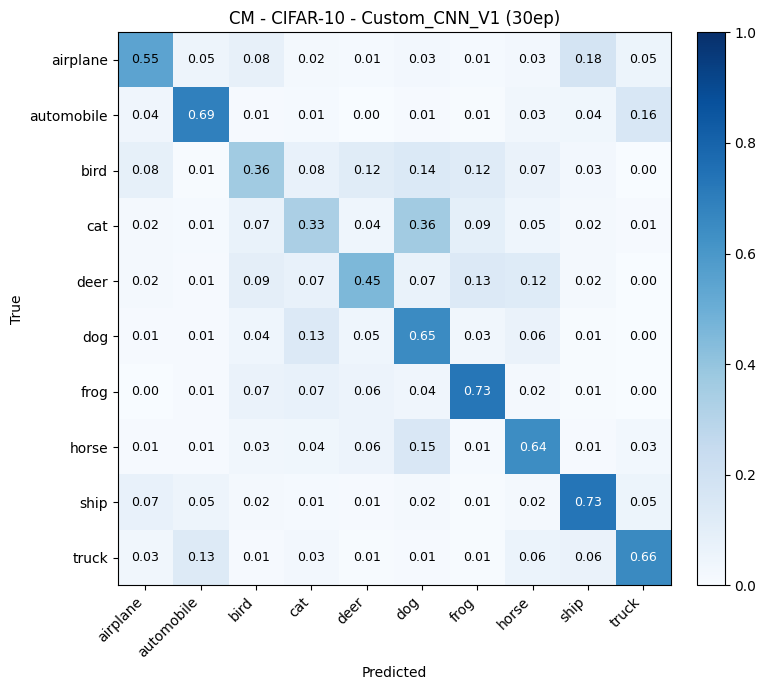

In [15]:
# Evaluate
criterion = nn.CrossEntropyLoss()

test_loss, test_acc, _, y_true, y_pred = evaluate(
    model_cnn_cifar,
    cifar_loaders["test"],
    criterion,
    device,
    return_preds=True
)

cm = confusion_matrix(
    y_true, y_pred,
    labels=list(range(cifar_num_classes))
)

print("Test loss:", test_loss)
print("Test acc :", test_acc)

print("Confusion matrix shape:", cm.shape)  # should be (10, 10)
plot_confusion_matrix(cm,cifar_class_names,title="CM - CIFAR-10 - Custom_CNN_V1 (30ep)")

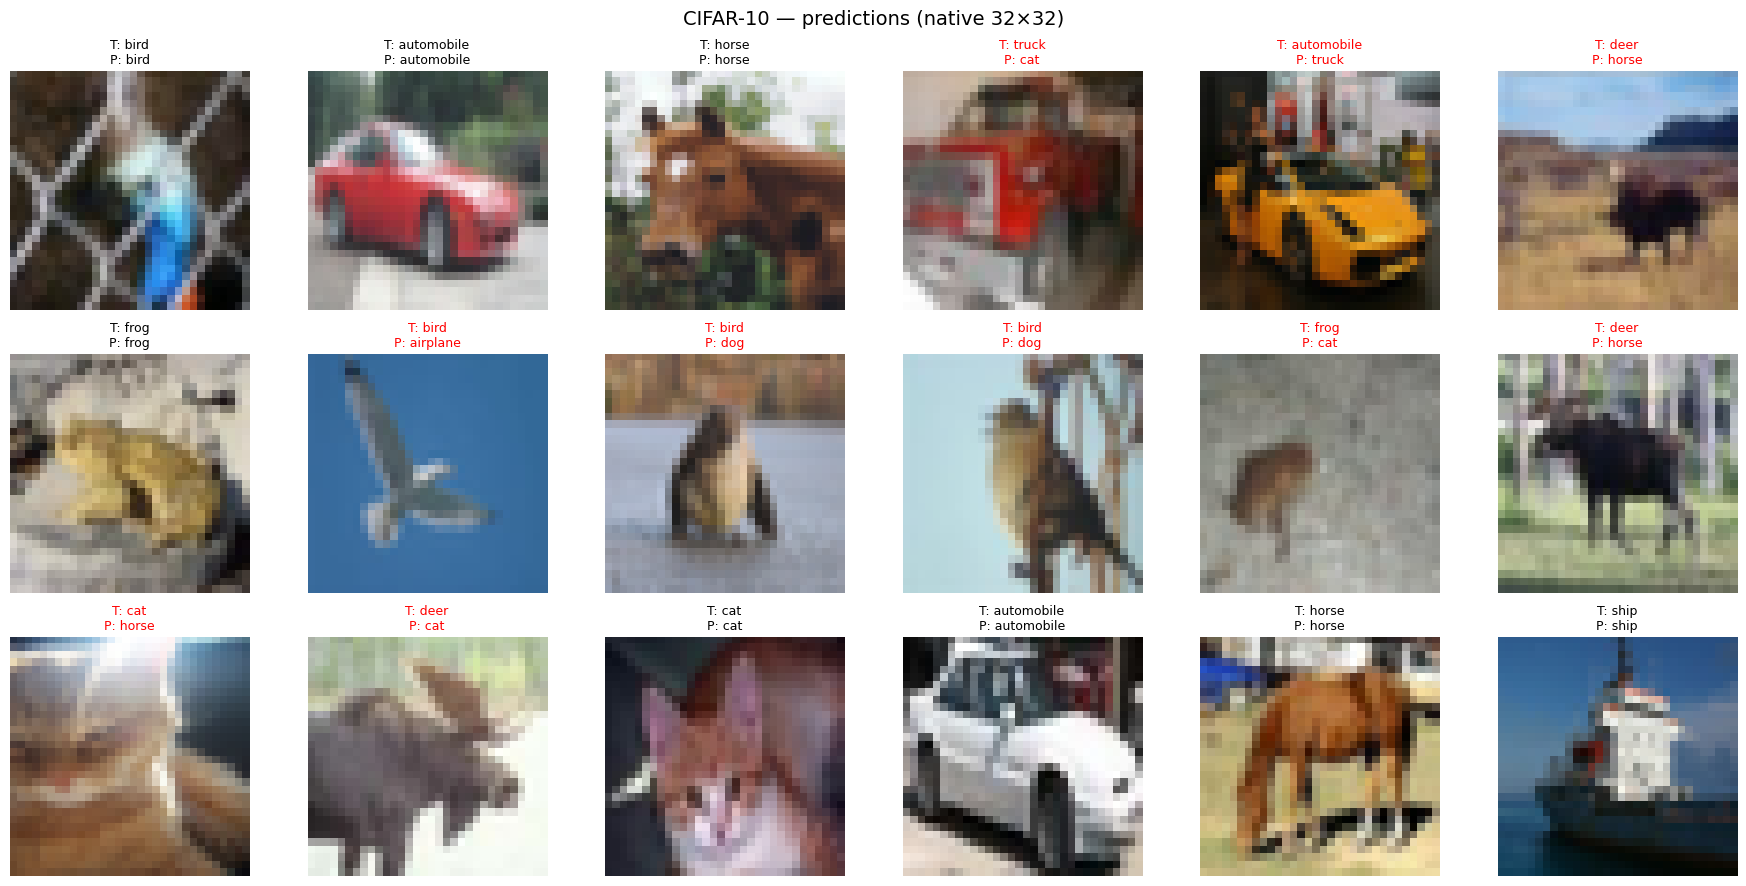

In [16]:
idxs = pick_indices(y_true, y_pred, n=18, only_errors=False, seed=0)
show_predictions_grid_viz(viz_cifar_test, idxs, y_true, y_pred, cifar_class_names,
                          title="CIFAR-10 — predictions (native 32×32)")

In [17]:
top_confusions(y_true, y_pred, cifar_class_names, top_k=10)

Top 10 confusions (true -> pred : count):
cat -> dog : 360
airplane -> ship : 178
automobile -> truck : 156
horse -> dog : 152
bird -> dog : 140
deer -> frog : 134
dog -> cat : 134
truck -> automobile : 130
deer -> horse : 123
bird -> frog : 120


##### Analysis

| Dataset | Model | Criterion | Optimizer | Learning Rate | Epochs | Best Epoch | Best Val Acc | Final Val Acc | Final Test Acc | Final Val Macro-F1 | Final Test Macro-F1 |
|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|
| CIFAR-10 | CNN_V1 | CrossEntropyLoss | AdamW | 3e-4 | 30 | 27 | 0.579 | 0.579 | 0.579 | 0.576 | 0.575 |

---

| Dataset | Model | Total Training Time | Train Peak Mem. Bytes | Val Peak Mem. Bytes | Test Peak Mem. Bytes |
|-----|-----|-----|-----|-----|-----|
| CIFAR-10 | CNN_V1 | 0h47 | 751 MB | 450.2 MB | 450.2 MB | 

**Losses/Metrics**

The metrics show that the best epoch was number 27 out of 30, which show that our training process converged. The final test accuracy is 58%, which indicates moderate performance. The validation and test accuracies are almost identical, 57.6% and 57.5%. This tells us that the model is not overfitted. The final test loss was 1.2, which is consistent with the observed accuracy; this value lies approximately halfway between a perfect result (test loss = 0) and the theoretical maximum loss for 10 classes (ln(10) ≈ 2.3).

**Predictions**

Analysis of the confusion matrix indicates that the model performs best on classes such as frogs, ships, and automobiles. When analysing the predictions, we observe that the top confusions are cat vs. dog, airplane vs. ship and automobile vs. truck. The objects that are confused have similar caracteristics, so it is understandable that these confusions occur. 

**Short conclusion**

The model is able to classify many entities in the CIFAR-10 dataset, but is not yet mature enought to be trustworthy. We will compare it to the more complex CNN model from scratch in the next section. 

#### 2.1.2 - CIFAR-10 - CNN (V2)

We will now fit the CNN_v2 model on the same dataset. This model has more convolutional blocks and uses BatchNorm.

##### Train

In [18]:
MODEL_NAME = "cnn_v2_cifar_30ep"
if TRAIN_CNN_V2_CIFAR:
    # Training
    cifar_num_classes = len(cifar_class_names)
    model_cnn_cifar = Custom_CNN_v2(num_classes=cifar_num_classes).to(device)

    model_cnn_cifar, history, metrics, saved_path = train_model(
        model=model_cnn_cifar,
        train_loader=cifar_loaders["train"],
        val_loader=cifar_loaders["val"],
        test_loader=cifar_loaders["test"],
        epochs=30,
        lr=3e-4, 
        device=device,
        save_folder_name=f"{MODEL_NAME}",
    )

    print("Saved to:", saved_path)
    print("Final metrics:", metrics)
    plot_history(history, title="CNN_V2 on CIFAR-10")
    
else:
    print(device)
    ckpt_path = f"weights/project_3/{MODEL_NAME}/{MODEL_NAME}_model_weights.pth"
    ckpt = torch.load(ckpt_path, map_location=device)

    cifar_num_classes = len(cifar_class_names)
    model_cnn_cifar = Custom_CNN_v2(num_classes=cifar_num_classes).to(device)
    model_cnn_cifar.load_state_dict(ckpt["model_state_dict"])
    print("Loaded checkpoint keys:", ckpt.keys())
    if "metrics" in ckpt:
        print("Saved metrics:", ckpt["metrics"])

mps
Loaded checkpoint keys: dict_keys(['model_state_dict', 'history', 'metrics', 'config'])
Saved metrics: {'best_val_acc': 0.682008785942492, 'best_epoch': 29, 'final_val_acc': 0.682008785942492, 'final_val_macro_f1': 0.6777418450969226, 'final_test_acc': 0.6842052715654952, 'final_test_macro_f1': 0.6814938404617283, 'total_training_time_sec': 3673.760349802, 'train_peak_mem_bytes': 1181895168, 'val_peak_mem_bytes': 455212544, 'test_peak_mem_bytes': 455212544, 'device': 'cuda', 'lr': 0.0003, 'epochs': 30}


##### Evaluate/Results

Test loss: 0.9038970738935014
Test acc : 0.6841054313099042
Confusion matrix shape: (10, 10)


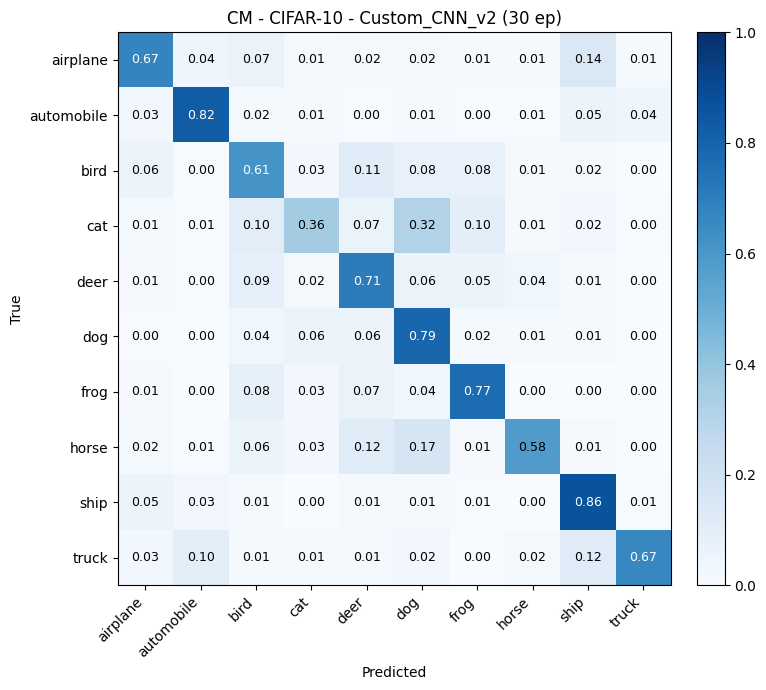

In [19]:
# Evaluate
criterion = nn.CrossEntropyLoss()

test_loss, test_acc, _, y_true, y_pred = evaluate(
    model_cnn_cifar,
    cifar_loaders["test"],
    criterion,
    device,
    return_preds=True
)

cm = confusion_matrix(
    y_true, y_pred,
    labels=list(range(cifar_num_classes))
)

print("Test loss:", test_loss)
print("Test acc :", test_acc)

print("Confusion matrix shape:", cm.shape)  # should be (10, 10)
plot_confusion_matrix(cm,cifar_class_names,title="CM - CIFAR-10 - Custom_CNN_v2 (30 ep)")

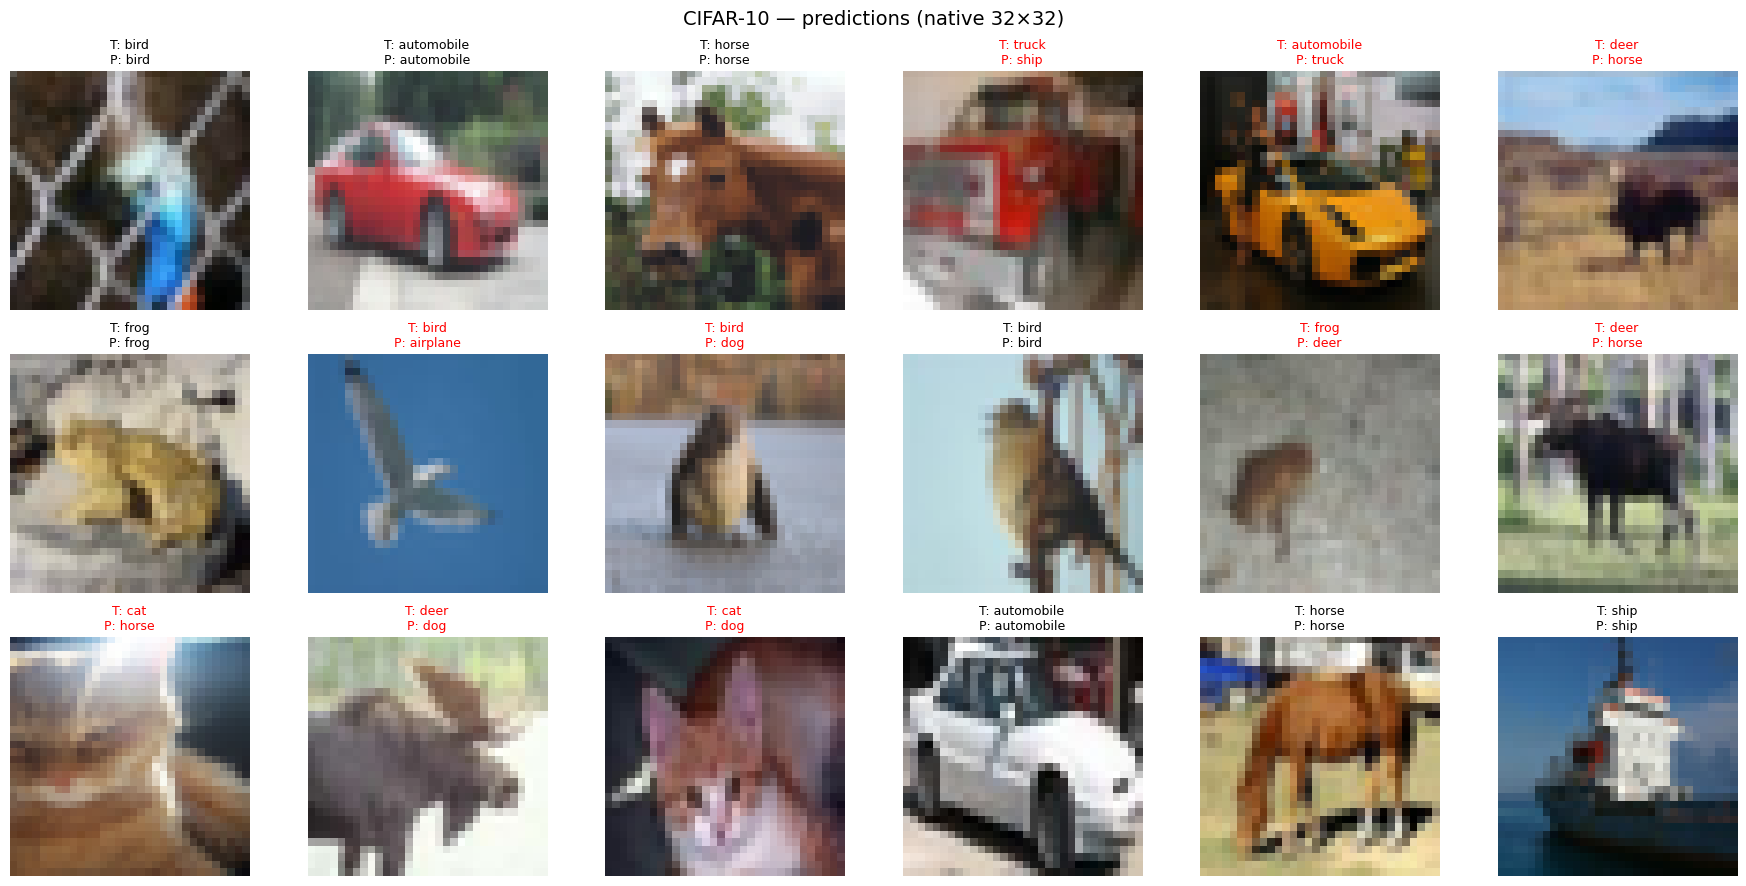

In [20]:
idxs = pick_indices(y_true, y_pred, n=18, only_errors=False, seed=0)
show_predictions_grid_viz(viz_cifar_test, idxs, y_true, y_pred, cifar_class_names,
                          title="CIFAR-10 — predictions (native 32×32)")

In [21]:
top_confusions(y_true, y_pred, cifar_class_names, top_k=10)

Top 10 confusions (true -> pred : count):
cat -> dog : 316
horse -> dog : 170
airplane -> ship : 142
truck -> ship : 121
horse -> deer : 119
bird -> deer : 114
truck -> automobile : 103
cat -> bird : 102
cat -> frog : 99
deer -> bird : 90


##### Analysis

| Dataset  | Model  | Criterion        | Optimizer | Learning Rate | Epochs | Best Epoch | Best Val Acc | Final Val Acc | Final Test Acc | Final Val Macro-F1 | Final Test Macro-F1 |
| -------- | ------ | ---------------- | --------- | ------------- | ------ | ---------- | ------------ | ------------- | -------------- | ------------------ | ------------------- |
| CIFAR-10 | CNN_V2 | CrossEntropyLoss | AdamW     | 3e-4          | 30     | 29         | 0.682        | 0.682         | 0.684          | 0.678              | 0.681               |

---
| Dataset  | Model  | Total Training Time | Train Peak Mem. Bytes | Val Peak Mem. Bytes | Test Peak Mem. Bytes |
| -------- | ------ | ------------------- | --------------------- | ------------------- | -------------------- |
| CIFAR-10 | CNN_V2 | 1h 1m 13s           | 1,181 MB              | 455 MB              | 455 MB               |


**Losses/Metrics**

The training process converged at epoch 29 out of 30. The final validation accuracy remained 68.2%, while the final test accuracy reached 68.4%, indicating that the model generalized well to unseen data. The macro-F1 scores were 0.678 for validation and 0.681 for testing, reflecting balanced performance across all ten CIFAR-10 classes. The final test loss was 0.904, which is consistent with the observed accuracy, lying approximately halfway between a perfect prediction (loss = 0) and the theoretical worst-case loss for ten classes (ln(10) ≈ 2.3). 

**Predictions**

Analysis of the confusion matrix shows that the model performs best on the classes ship (86%), automobiles (82%), and dogs (79%).. The top three confusions observed in the test set were cat misclassified as dog (316 instances), horse misclassified as dog (170 instances), airplane misclassified as ship (142 instances). Most of these misclassifications occurred between visually similar classes, as with the Custom_CNN model.

**Short conclusion**

The Custom_CNN_v2 model was able to classify the CIFAR-10 dataset better than the Custom_CNN, achieving a final test accuracy of 68.4% and a macro-F1 score of 0.681. We will therefore keep Custom_CNN_v2 for the training of the Food-101 dataset. The closeness of validation and test metrics suggests minimal overfitting. Some confusion exists between visually similar classes, such as cats and dogs or airplanes and ships, indicating that further improvements could be obtained through more complex architectures or additional data augmentation. 

#### 2.1.3 - Food-101 - CNN (V2)

We saw that CNN_v2 gave better results, we will there use this model on the food dataset, and discard the CVV_v1. 

##### Train

In [22]:
MODEL_NAME = "cnn_v2_food_30ep"
if TRAIN_CNN_V2_FOOD:
    # Training
    food_num_classes = len(food_class_names)
    model_cnn_food = Custom_CNN_v2(num_classes=food_num_classes).to(device)

    model_cnn_food, history, metrics, saved_path = train_model(
        model=model_cnn_food,
        train_loader=food_loaders["train"],
        val_loader=food_loaders["val"],
        test_loader=food_loaders["test"],
        epochs=30,
        lr=3e-4, 
        device=device,
        save_folder_name=f"{MODEL_NAME}",
    )

    print("Saved to:", saved_path)
    print("Final metrics:", metrics)
    plot_history(history, title="CNN on Food-101")

else:
    print(device)
    ckpt_path = f"weights/project_3/{MODEL_NAME}/{MODEL_NAME}_model_weights.pth"
    ckpt = torch.load(ckpt_path, map_location=device)

    food_num_classes = len(food_class_names)
    model_cnn_food = Custom_CNN_v2(num_classes=food_num_classes).to(device)
    model_cnn_food.load_state_dict(ckpt["model_state_dict"])
    print("Loaded checkpoint keys:", ckpt.keys())
    if "metrics" in ckpt:
        print("Saved metrics:", ckpt["metrics"])

mps
Loaded checkpoint keys: dict_keys(['model_state_dict', 'history', 'metrics', 'config'])
Saved metrics: {'best_val_acc': 0.45724080773345527, 'best_epoch': 29, 'final_val_acc': 0.45724080773345527, 'final_val_macro_f1': 0.44946140405671176, 'final_test_acc': 0.5090981012658228, 'final_test_macro_f1': 0.4999424914852357, 'total_training_time_sec': 11659.421335477, 'train_peak_mem_bytes': 1675534848, 'val_peak_mem_bytes': 953570816, 'test_peak_mem_bytes': 953570816, 'device': 'cuda', 'lr': 0.0003, 'epochs': 30}


##### Evaluate/Results

In [23]:
# Evaluate
criterion = nn.CrossEntropyLoss()

test_loss, test_acc, _, y_true, y_pred = evaluate(
    model_cnn_food,
    food_loaders["test"],
    criterion,
    device,
    return_preds=True
)

print("Test loss:", test_loss)
print("Test acc :", test_acc)

Test loss: 1.9975596635590627
Test acc : 0.5089794303797468


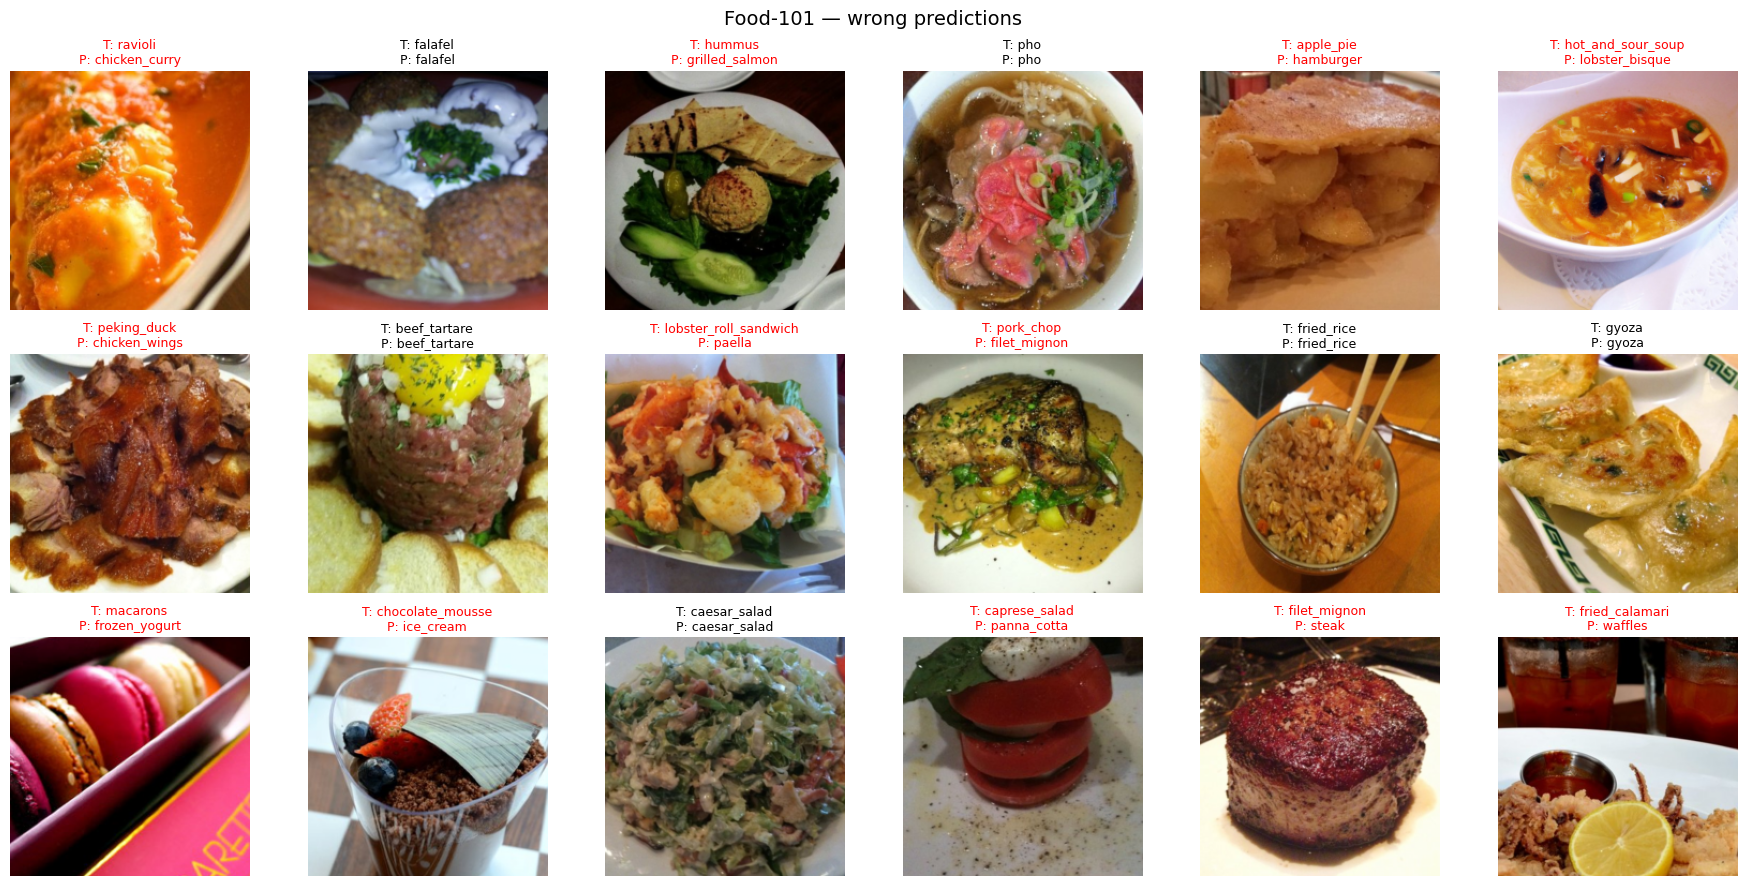

In [24]:
idxs = pick_indices(y_true, y_pred, n=18, only_errors=False, seed=0)
show_predictions_grid(test_food, idxs, y_true, y_pred, food_class_names, IMAGENET_MEAN_TENSOR, IMAGENET_STD_TENSOR,
                          title="Food-101 — wrong predictions")

In [25]:
top_confusions(y_true, y_pred, food_class_names, top_k=10)

Top 10 confusions (true -> pred : count):
steak -> filet_mignon : 59
steak -> baby_back_ribs : 51
pork_chop -> filet_mignon : 42
onion_rings -> french_fries : 42
cheesecake -> panna_cotta : 41
ramen -> pho : 37
samosa -> spring_rolls : 33
pulled_pork_sandwich -> hamburger : 33
chocolate_cake -> cheesecake : 33
apple_pie -> bread_pudding : 32


##### Analysis

| Dataset  | Model  | Criterion        | Optimizer | Learning Rate | Epochs | Best Epoch | Best Val Acc | Final Val Acc | Final Test Acc | Final Val Macro-F1 | Final Test Macro-F1 |
| -------- | ------ | ---------------- | --------- | ------------- | ------ | ---------- | ------------ | ------------- | -------------- | ------------------ | ------------------- |
| FOOD-101 | CNN_V2 | CrossEntropyLoss | AdamW     | 3e-4          | 30     | 29         | 0.457        | 0.457         | 0.509          | 0.449              | 0.500               |

---

| Dataset  | Model  | Total Training Time | Train Peak Mem. Bytes | Val Peak Mem. Bytes | Test Peak Mem. Bytes |
| -------- | ------ | ------------------- | --------------------- | ------------------- | -------------------- |
| FOOD-101 | CNN_V2 | 3h 14m 19s          | 1,675 MB              | 954 MB              | 954 MB               |


**Losses/Metrics**

The training process converged at epoch 29. The final validation accuracy remained 45.7%, while the final test accuracy reached 50.9%, indicating good generalization to unseen data, but still some overfitting. The macro-F1 scores were 0.449 for validation and 0.500 for testing, reflecting balanced performance across all 101 classes. The final test loss was 1.998, consistent with the accuracy metrics, and lying roughly between a perfect prediction (loss = 0) and the theoretical worst-case loss for 101 classes (ln(101) ≈ 4.615).

**Predictions**

Analysis of the confusion matrix shows that the model performs best on classes with distinctive visual features, while several misclassifications occur between visually similar food items. The top five confusions in the test set were:

- steak → filet_mignon : 59
- steak → baby_back_ribs : 51
- pork_chop → filet_mignon : 42
- onion_rings → french_fries : 42
- cheesecake → panna_cotta : 41

These misclassifications are reasonable given the visual similarity between some dishes, for example steak and filet mignon, or cheesecake and panna cotta.

**Short conclusion**

The CNN_V2 model demonstrates moderate performance on the FOOD-101 dataset, achieving a final test accuracy of 50.9% and a macro-F1 score of 0.500. It obtained a higher performance for the CIFAR-10 dataset. This makes sense as it is a dataset with far fewer classes and is therefor easier to learn. The similarity between validation and test metrics indicates minimal overfitting. Misclassifications mainly occur between visually similar food items, which suggests that further improvements could be achieved through a more complex architecture or additional data augmentation. 

### 2.2 - ResNet-18

We will now apply the ResNet18 model for multiclass classification on both datasets: CIFAR and Food. ResNet is a more complex architecture, and is widely used for tasks like the one we are performing in this project.Talk about ResNet - comarison with CNN with classification. 

#### 2.2.1 - ResNet-18 - CIFAR-10

##### Train

In [28]:
MODEL_NAME = "cnn_resnet_cifar_30ep"
if TRAIN_RESNET_CIFAR:
    # Training
    cifar_num_classes = len(cifar_class_names)
    model_resnet_cifar = ResNet18(num_classes=cifar_num_classes).to(device)

    model_resnet_cifar, history, metrics, saved_path = train_model_resnet(
        model=model_resnet_cifar,
        train_loader=cifar_loaders["train"],
        val_loader=cifar_loaders["val"],
        test_loader=cifar_loaders["test"],
        momentum = 0.9,
        weight_decay = 5e-4,
        epochs=30,
        lr=1e-5, 
        device=device,
        save_folder_name=f"{MODEL_NAME}",
    )

    print("Saved to:", saved_path)
    print("Final metrics:", metrics)
    plot_history(history, title="ResNet18 on CIFAR-10")
    
else:
    print(device)
    ckpt_path = f"weights/project_3/{MODEL_NAME}/{MODEL_NAME}_model_weights.pth"
    ckpt = torch.load(ckpt_path, map_location=device)

    cifar_num_classes = len(cifar_class_names)
    model_resnet_cifar = ResNet18(num_classes=cifar_num_classes).to(device)
    model_resnet_cifar.load_state_dict(ckpt["model_state_dict"])
    print("Loaded checkpoint keys:", ckpt.keys())
    if "metrics" in ckpt:
        print("Saved metrics:", ckpt["metrics"])

mps
Loaded checkpoint keys: dict_keys(['model_state_dict', 'history', 'metrics', 'config'])
Saved metrics: {'best_val_acc': 0.6242012779552716, 'best_epoch': 30, 'final_val_acc': 0.6242012779552716, 'final_val_macro_f1': 0.6234692421021206, 'final_test_acc': 0.6293929712460063, 'final_test_macro_f1': 0.6296887961346983, 'total_training_time_sec': 3523.716721146, 'train_peak_mem_bytes': 1210045952, 'val_peak_mem_bytes': 695952896, 'test_peak_mem_bytes': 695952896, 'device': 'cuda', 'lr': 1e-05, 'epochs': 30}


##### Evaluate/Results

Test loss: 1.0391101538182828
Test acc : 0.6295926517571885
Confusion matrix shape: (10, 10)


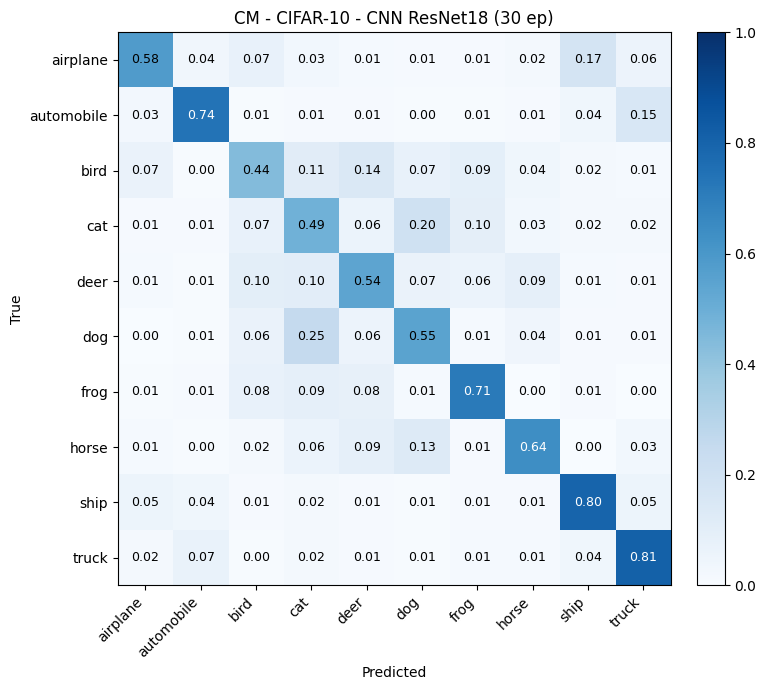

In [29]:
# Evaluate
criterion = nn.CrossEntropyLoss()

test_loss, test_acc, _, y_true, y_pred = evaluate(
    model_resnet_cifar,
    cifar_loaders["test"],
    criterion,
    device,
    return_preds=True
)

cm = confusion_matrix(
    y_true, y_pred,
    labels=list(range(cifar_num_classes))
)

print("Test loss:", test_loss)
print("Test acc :", test_acc)

print("Confusion matrix shape:", cm.shape)  # should be (10, 10)
plot_confusion_matrix(cm,cifar_class_names,title="CM - CIFAR-10 - CNN ResNet18 (30 ep)")

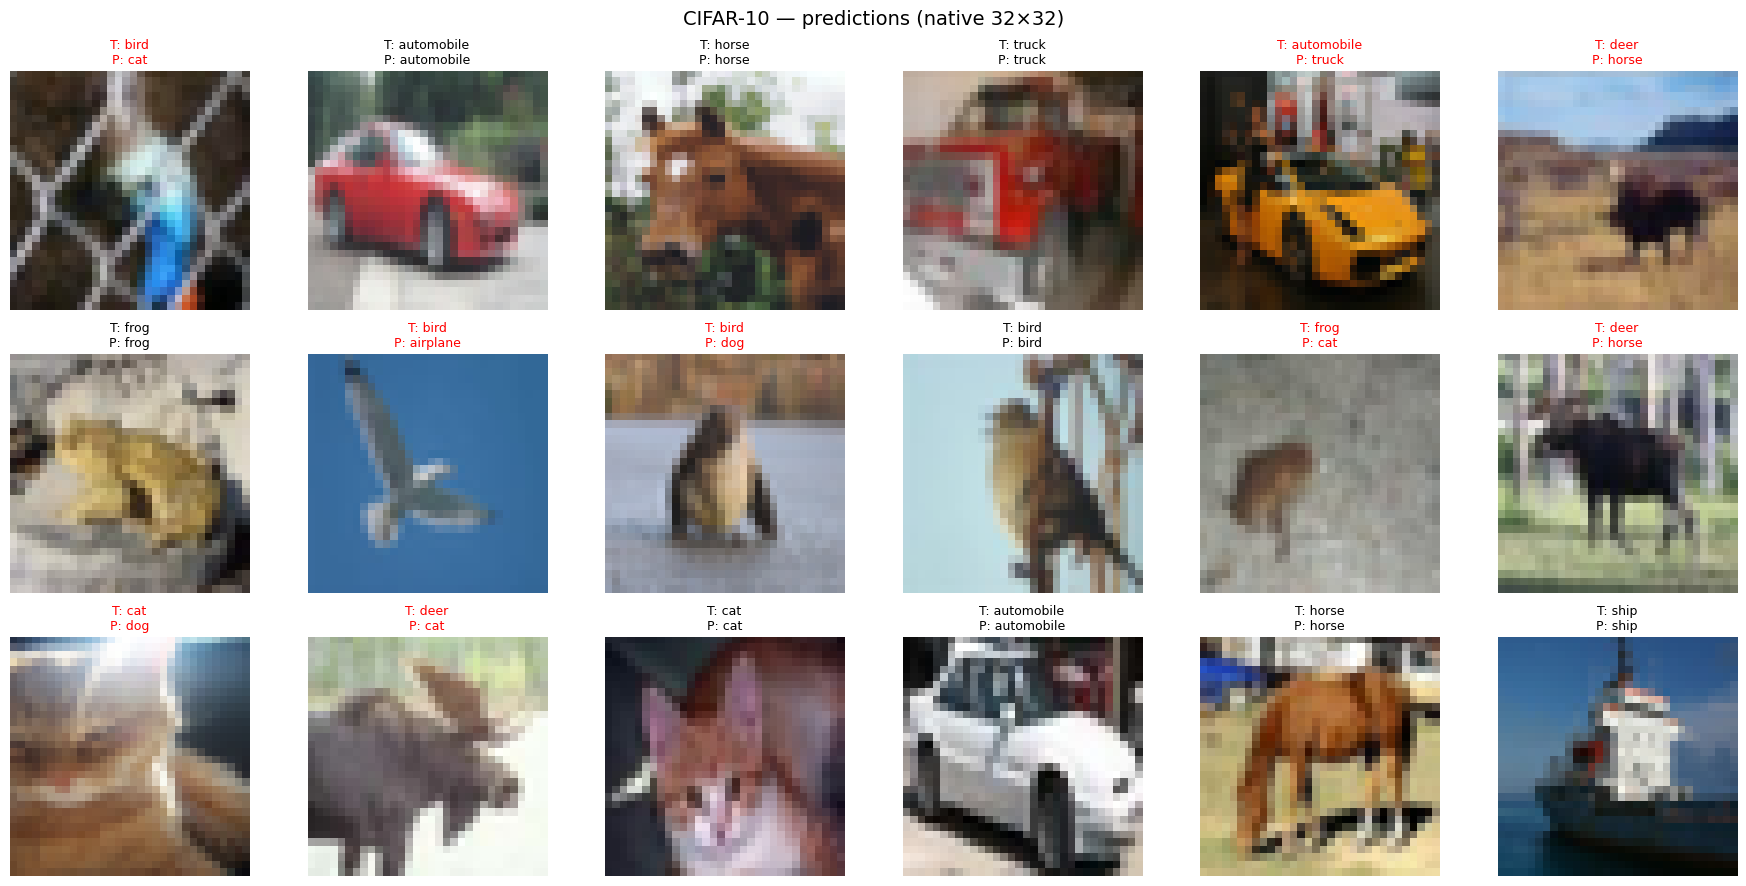

In [30]:
idxs = pick_indices(y_true, y_pred, n=18, only_errors=False, seed=0)
show_predictions_grid_viz(viz_cifar_test, idxs, y_true, y_pred, cifar_class_names,
                          title="CIFAR-10 — predictions (native 32×32)")


In [31]:
top_confusions(y_true, y_pred, cifar_class_names, top_k=10)

Top 10 confusions (true -> pred : count):
dog -> cat : 252
cat -> dog : 201
airplane -> ship : 172
automobile -> truck : 155
bird -> deer : 141
horse -> dog : 129
bird -> cat : 112
deer -> cat : 103
deer -> bird : 101
cat -> frog : 96


##### Analysis

| Dataset  | Model     | Criterion        | Optimizer | Learning Rate | Epochs | Best Epoch | Best Val Acc | Final Val Acc | Final Test Acc | Final Val Macro-F1 | Final Test Macro-F1 |
| -------- | --------- | ---------------- | --------- | ------------- | ------ | ---------- | ------------ | ------------- | -------------- | ------------------ | ------------------- |
| CIFAR-10 | ResNet-18 | CrossEntropyLoss | AdamW     | 1e-5          | 30     | 30         | 0.624        | 0.624         | 0.629          | 0.623              | 0.630               |

---

| Dataset  | Model     | Total Training Time | Train Peak Mem. Bytes | Val Peak Mem. Bytes | Test Peak Mem. Bytes |
| -------- | --------- | ------------------- | --------------------- | ------------------- | -------------------- |
| CIFAR-10 | ResNet-18 | 0h 58m 44s          | 1,210 MB              | 696 MB              | 696 MB               |


**Losses/Metrics**


The best epoch of the ResNet-18 model was epoch 30, which suggests that the training process has not yet fully converged. This is confirmed by visually inspecting the loss curves. We see that we could with advantage run the model on more epochs. However, we made the choice to cut the training at 30 epochs to compare with the rest of the models in this project. This was also due to time constraints. The final validation accuracy remained 62.4%, while the final test accuracy reached 62.9%, indicating consistent generalization to unseen data, no overfitting. The final test loss was 1.039, consistent with the accuracy metrics, and within the expected range for a ten-class classification problem

**Predictions**


Examination of the confusion matrix indicates that the model performs best on classes with distinctive features, while misclassifications tend to occur between visually similar classes. The top three confusions in the test set were:

- dog → cat : 253
- cat → dog : 200
- airplane → ship : 172

This is similar to the misclassifications with the CNN from-scratch models on the same dataset.

**Short conclusion**

The ResNet-18 model achieved moderate performance on the CIFAR-10 dataset, with a final test accuracy of 62.9% and a macro-F1 score of 0.630. The closeness of validation and test metrics suggests minimal overfitting. Misclassifications mainly occurred between visually similar classes, highlighting areas where additional data augmentation or more complex architectures could further improve performance. It is important to note that the training process did not yet converge, meaning we could have obtained better metrics. With 30 epochs, the Custom_CNN_v2 performs slightly better than ResNet18 on CIFAR-10. However, we do not know if this would still be the case if we trained with more epochs. 

#### 2.2.2 - ResNet-18 - Food-101

##### Train

In [32]:
MODEL_NAME = "cnn_resnet_food_30ep"
if TRAIN_RESNET_FOOD:
    # Training
    food_num_classes = len(food_class_names)
    model_resnet_food = ResNet18(num_classes=food_num_classes).to(device)

    model_resnet_food, history, metrics, saved_path = train_model_resnet(
        model=model_resnet_food,
        train_loader=food_loaders["train"],
        val_loader=food_loaders["val"],
        test_loader=food_loaders["test"],
        momentum = 0.9,
        weight_decay = 5e-4,
        epochs=30,
        lr=3e-4, 
        device=device,
        save_folder_name=f"{MODEL_NAME}",
    )

    print("Saved to:", saved_path)
    print("Final metrics:", metrics)
    plot_history(history, title="ResNet18 on Food-101")

else:
    print(device)
    ckpt_path = f"weights/project_3/{MODEL_NAME}/{MODEL_NAME}_model_weights.pth"
    ckpt = torch.load(ckpt_path, map_location=device)

    food_num_classes = len(food_class_names)
    model_resnet_food = ResNet18(num_classes=food_num_classes).to(device)
    model_resnet_food.load_state_dict(ckpt["model_state_dict"])
    print("Loaded checkpoint keys:", ckpt.keys())
    if "metrics" in ckpt:
        print("Saved metrics:", ckpt["metrics"])

mps
Loaded checkpoint keys: dict_keys(['model_state_dict', 'history', 'metrics', 'config'])
Saved metrics: {'best_val_acc': 0.5720878541469574, 'best_epoch': 27, 'final_val_acc': 0.5720878541469574, 'final_val_macro_f1': 0.5726298532998038, 'final_test_acc': 0.6331487341772152, 'final_test_macro_f1': 0.6334536797768249, 'total_training_time_sec': 11339.003532028002, 'train_peak_mem_bytes': 1304780800, 'val_peak_mem_bytes': 789770240, 'test_peak_mem_bytes': 789770240, 'device': 'cuda', 'lr': 0.0003, 'epochs': 30}


##### Evaluate/Results

In [33]:
# Evaluate
criterion = nn.CrossEntropyLoss()

test_loss, test_acc, _, y_true, y_pred = evaluate(
    model_resnet_food,
    food_loaders["test"],
    criterion,
    device,
    return_preds=True
)

print("Test loss:", test_loss)
print("Test acc :", test_acc)

Test loss: 1.3914418758930567
Test acc : 0.6331091772151899


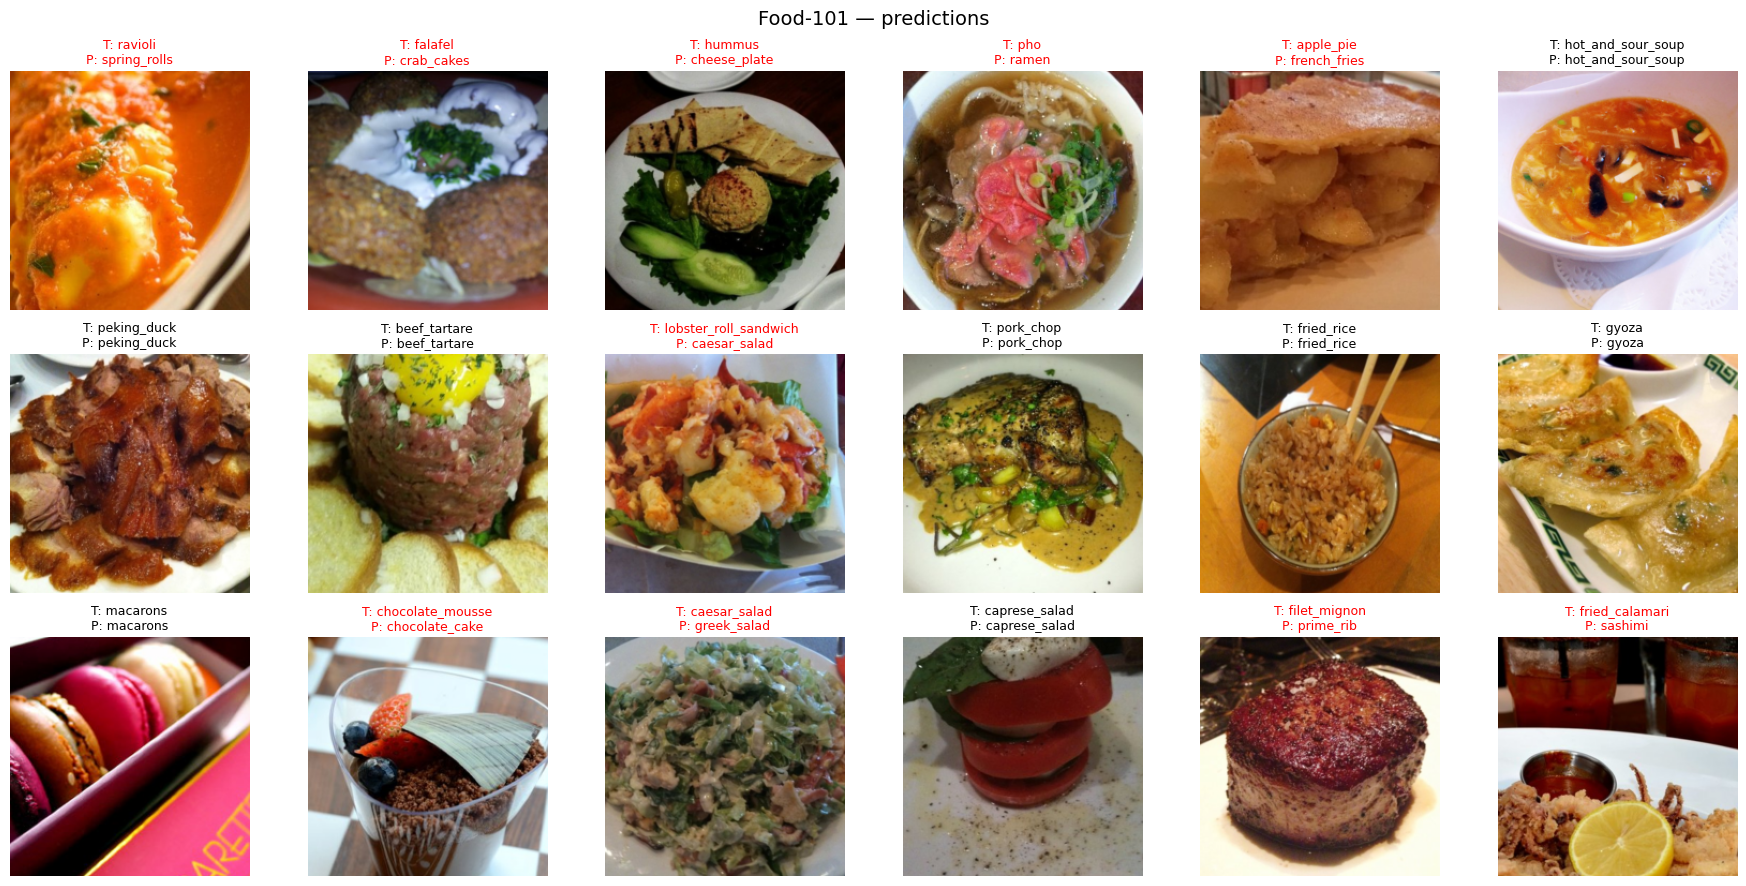

In [34]:
idxs = pick_indices(y_true, y_pred, n=18, only_errors=False, seed=0)
show_predictions_grid(test_food, idxs, y_true, y_pred, food_class_names, IMAGENET_MEAN_TENSOR, IMAGENET_STD_TENSOR,
                          title="Food-101 — predictions")

In [35]:
top_confusions(y_true, y_pred, food_class_names, top_k=10)

Top 10 confusions (true -> pred : count):
steak -> filet_mignon : 59
samosa -> spring_rolls : 38
chocolate_cake -> chocolate_mousse : 36
nachos -> tacos : 36
risotto -> fried_rice : 32
steak -> prime_rib : 30
hamburger -> pulled_pork_sandwich : 30
spaghetti_bolognese -> pad_thai : 26
donuts -> cup_cakes : 26
gnocchi -> ravioli : 25


##### Analysis

| Dataset  | Model     | Criterion        | Optimizer | Learning Rate | Epochs | Best Epoch | Best Val Acc | Final Val Acc | Final Test Acc | Final Val Macro-F1 | Final Test Macro-F1 |
| -------- | --------- | ---------------- | --------- | ------------- | ------ | ---------- | ------------ | ------------- | -------------- | ------------------ | ------------------- |
| FOOD-101 | ResNet-18 | CrossEntropyLoss | AdamW     | 3e-4          | 30     | 27         | 0.572        | 0.572         | 0.633          | 0.573              | 0.633               |


---

| Dataset  | Model     | Total Training Time | Train Peak Mem. Bytes | Val Peak Mem. Bytes | Test Peak Mem. Bytes |
| -------- | --------- | ------------------- | --------------------- | ------------------- | -------------------- |
| FOOD-101 | ResNet-18 | 3h 9m 59s           | 1,305 MB              | 790 MB              | 790 MB               |

**Losses/Metrics**
The training process converged at epoch 27, indicating that the training process converged. The final validation accuracy remained 57.2%, while the final test accuracy reached 63.3%, demonstrating that the model generalized reasonably well to unseen data. The final test loss was 1.747, which aligns with the observed accuracy and reflects the difficulty of the Food 101-class classification task.

**Predictions**
Analysis of the confusion matrix shows that the model performs best on classes with distinctive visual features, while misclassifications tend to occur between visually similar dishes. The top confusions in the test set were:

- steak → filet_mignon : 59

- samosa → spring_rolls : 38

- chocolate_cake → chocolate_mousse : 36

These misclassifications are reasonable given the visual similarity of them. Similar to the Custum_CNN_v2, filet mignon and steak was the most misclassified. 

**Short conclusion**
The ResNet-18 model achieved moderate performance on the FOOD-101 dataset, with a final test accuracy of 63.3% and a macro-F1 score of 0.633. The performance was significantly better than the results with the Custum_CNN_v2 model. The closeness of validation and test metrics suggests limited overfitting. Most errors occurred between visually similar dishes, indicating that further improvements could be obtained through more complex architectures, additional training data, or advanced data augmentation. The checkpoint saved model weights, training history, and metrics to ensure reproducibility.

### 2.3 - Conclusion on CNNs

The summarised results of the five training processes can be found in the following table: 

| Dataset  | Model     | Epochs | Best Epoch | Best Val Acc | Final Val Acc | Final Test Acc | Final Val Macro-F1 | Final Test Macro-F1 |
| -------- | --------- | ------ | ---------- | ------------ | ------------- | -------------- | ------------------ | ------------------- |
| CIFAR-10 | CNN_V1    | 30     | 27         | 0.579        | 0.579         | 0.579          | 0.576              | 0.575               |
| CIFAR-10 | CNN_V2    | 30     | 29         | 0.682        | 0.682         | 0.684          | 0.678              | 0.681               |
| FOOD-101 | CNN_V2    | 30     | 29         | 0.457        | 0.457         | 0.509          | 0.449              | 0.500               |
| CIFAR-10 | ResNet-18 | 30     | 30         | 0.624        | 0.624         | 0.629          | 0.623              | 0.630               |
| FOOD-101 | ResNet-18 | 30     | 27         | 0.572        | 0.572         | 0.633          | 0.573              | 0.633               |

And the corresponding resource usage in this table: 
| Dataset  | Model     | Total Training Time | Train Peak Mem. Bytes | Val Peak Mem. Bytes | Test Peak Mem. Bytes |
| -------- | --------- | ------------------- | --------------------- | ------------------- | -------------------- |
| CIFAR-10 | CNN_V1    | 0h 47m              | 751 MB                | 450 MB              | 450 MB               |
| CIFAR-10 | CNN_V2    | 1h 1m 13s           | 1,181 MB              | 455 MB              | 455 MB               |
| FOOD-101 | CNN_V2    | 3h 14m 19s          | 1,675 MB              | 954 MB              | 954 MB               |
| CIFAR-10 | ResNet-18 | 0h 58m 44s          | 1,210 MB              | 696 MB              | 696 MB               |
| FOOD-101 | ResNet-18 | 3h 9m 59s           | 1,305 MB              | 790 MB              | 790 MB               |

Overall, the results indicate that the more complex CNN_V2 model outperformed the simpler CNN_V1 model on the CIFAR-10 dataset. Consequently, the Food-101 experiments were conducted only with the CNN_V2 and ResNet-18 architectures.

For CIFAR-10, CNN_V2 achieved higher accuracy than ResNet-18 after 30 epochs, with a final test accuracy of 68.2% compared to 62.9%. However, the ResNet-18 model had not fully converged within 30 epochs, so it is not possible to conclude that it is inherently less effective than CNN_V2.

For Food-101, ResNet-18 outperformed CNN_V2 by a substantial margin, achieving a best validation accuracy of 57.2% compared to 45.7%. Given the large number of classes in the Food-101 dataset, it is reasonable that a more complex architecture would perform better than a simpler one.

## 3 - Vision Transformers

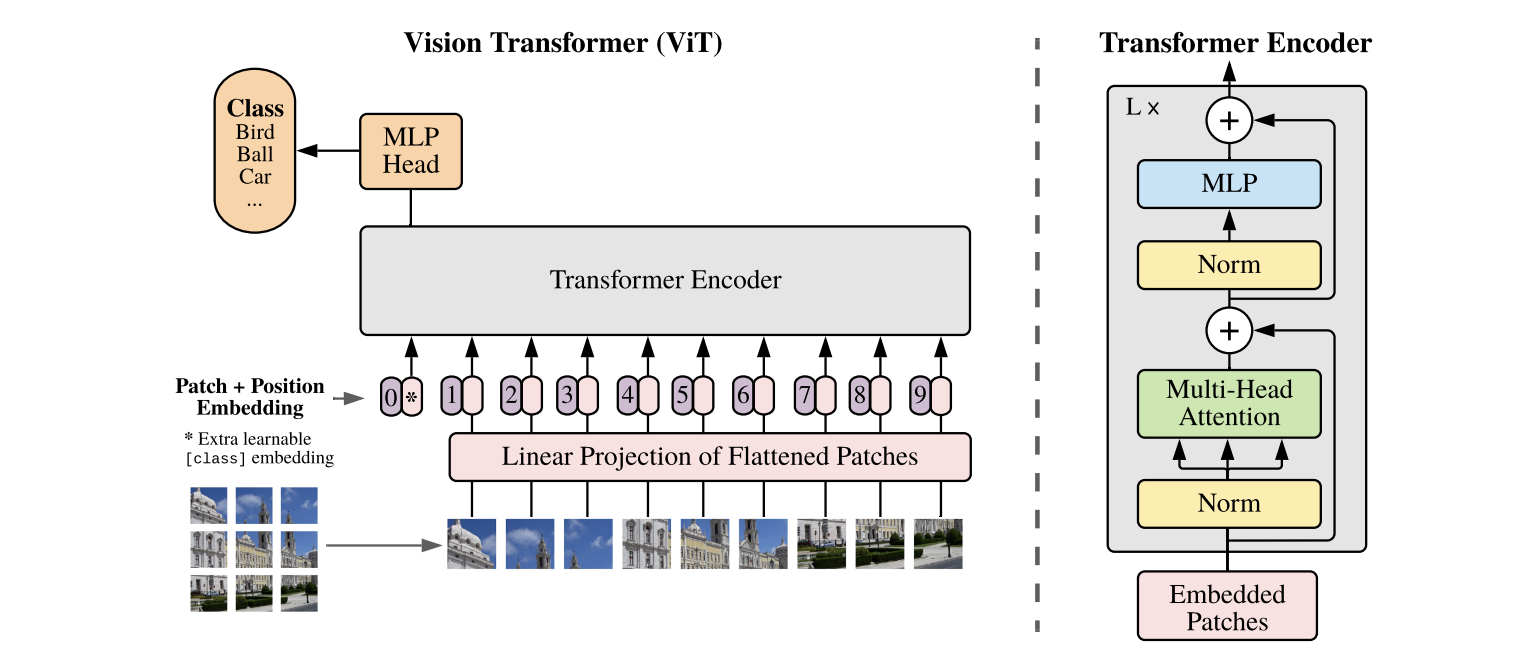

In [36]:
display(Image(filename="images/images_project_3/vit_architecture.png"))

### 3.1 - Introduction to Vision Transformers

Vision Transformers (ViTs) [1] were introduced in 2021 with the idea of proposing a model based on Transformers but for computer vision, and more precisely image recognition. Before ViTs, state-of-the-art models were mainly CNN-based architecture or CNNs with specific self attention mechanisms. However, even if they were efficient, these architectures were not scalable. ViTs aim at proposing an efficient computer vision model for image recognition that can be "scaled effectively on modern hardware" (GPUs).

The training process is as follows : An image is splitted into fixed-size patches, each patch is embedded and combined with position embeddings. This processed sequence of vectors is fed to a standard Transformer encoder, which include multi-head attention, MLP, layer norms and residual connections.

##### Input pre-processing
- According to [1], a Vision Transformers reshapes 2D images $x \in \mathbb{R}^{H \times W \times C}$ into a sequence of flattened 2D patches $x_p \in \mathbb{R}^{N \times (P^2.C)}$, where $(H,W)$ is the resolution of the original image, $C$ the number of channels, $(P,P)$ the resolution of each image patch, and $N = \frac{HW}{P^2}$ is the resulting number of patches, which also serves as the input sequence length for the Transformer.
- The flattened patches $x_p$ are then projected from $\mathbb{R}^{N \times (P^2.C)}$ to $\mathbb{R}^{D}$ to form a patch embedding $E$. This a learnable projection, such that $E = x_p W_E + b_E$, $W_E \in \mathbb{R}^{(P^2 C) \times D}$, $E \in \mathbb{R}^{N \times D}$
- As ViTs are inspired by Transformers, [1] mentions concatenating the patch embedding $E$ with a [CLS] token, to mimic what's being done with the [CLASS] token in BERT, such that $z_0 = [x_{CLS}, E] \in \mathbb{R}^{(N+1) \times D}$, with $x_{CLS} \in \mathbb{R}^{1 \times D}$. However, some implementations of ViTs use mean pooling for this step ($z_0 = E$).
- Finally, positional embedding is added to $z_0$, because transformers are permutation-invariant : $z_0 := z_0 + P_{pos}$, $P_{pos} \in \mathbb{R}^{(N+1) \times D}$.

##### The Transformer Encoder (L blocks)
- Let's $z$ be our pre-processed sequence of input tokens, meaning $z \in \mathbb{R}^{(N+1) \times D}$, before entering the Multi-Head Attention block, LayerNorm() is applied per token, over the dimension $D$.
- $z$ is then processed through a multi-head self-attention block and added to the unnormalized input tokens $z$, such that $\~z = z + MHSA(LN(z))$
- Before entering the Multi-Layer Perceptron block, $\~z$ is normalized once again, and then $LN(\~z)$ is processed through the MLP such that, $z' = \~z + MLP(LN(\~z))$
- $z'$ is then processed through the next encoder block. There are $L$ successive blocks in the architecture. $L$ is a hyperparemeter, but for standard ViT architectures we have L=12 (ViT-B/16), or L=24 (ViT-L/16).
- After the L encoder blocks, we have a sequence of tokens $z'_{L} \in \mathbb{R}^{(N+1) \times D}$ that is normalized, such that $y = LN(z'_{L}) \in \mathbb{R}^{(N+1) \times D}$.
- The token at index 0 is the CLS token, token indices from 1 to N are the patch tokens, and each token is a D-dimensional feature vector.
- For multi-class ($k$ classes) problem, this normalized sequence of tokens, is turned into a single vector. As the CLS token participates (in each attention layer) in self-attention with all tokens, it represents the image we want to classify. The CLS token has its own query $q_{CLS}$. Its updated value depends on the dot products with keys from every token (CLS and allpatches), producing weights that mix information from everywhere.
- So we take the CLS token $v = y_0 \in \mathbb{R}^{D}$ (the CLS token output is the first row of $y$)
- The CLS embedding is then mapped into K class scores, i.e. $logits \in \mathbb{R}^{K}$  : $logits = vW + b$, with $W \in \mathbb{R}^{D \times K}$ a weight matrix, for which the $k$-th column is weight vector $w_k \in \mathbb{R}^{D}$. So the logits for class $k$ are $logits_{k} = v^{T}w_k + b_k$. The model predicts a high score for class $k$ when the CLS representation $v$ aligns with $k$.
- Finally, logits are converted to probabilities with softmax : $p_k = \frac{e^{logits_k}}{\sum_{j=1}^{K}e^{logits_j}}$, with $p_k \in {0,1}$ and $\sum_{k=1}^{K}p_{k} = 1$.

##### Multi-Head Self-Attention
- In the previous paragraph, we have briefly introduced the multi-head self-attention (MSHA) block with : $\~z = z + MHSA(LN(z))$.
- Let $X = LN(z) \in \mathbb{R}^{(N+1) \times D}$. Vision Transformers rely in learned linear projections $Q = X W_Q$, $K = X W_K$, and $V = X W_V$, with $W_Q, W_K, W_V \in \mathbb{R}^{(D \times D)}$, and $Q, K, V \in \mathbb{R}^{(N+1) \times D}$, such that $[Q, K, V] = XU_{qkv}, U_{qkv} \in \mathbb{R}^{D \times 3D_h}$, where $D_h$ is the per-head dimension defined by $D_h = D/k$, with $k$ the number of heads.
- For $k$ heads, and for each head $i$, we have $Q^{(i)} = XW_{Q}^{(i)}$, $K^{(i)} = XW_{K}^{(i)}$, $V^{(i)} = XW_{V}^{(i)}$, with $Q^{(i)}, K^{(i)}, V^{(i)} \in \mathbb{R}^{(N+1) \times D_h}$
- The attention weights $A^{(i)}$ are based on the pairwise similarity between two elements of the sequence and their respective query $Q^{(i)}$ and key $K^{(i)}$ representations. We have $A^{(i)} = softmax(\frac{Q^{(i)} {K^{(i)}}^{T}}{\sqrt{D_h}}) \in \mathbb{R}^{(N+1)\times(N+1)}$
- The self-attention is then computed as $SA_{i}(X) = A^{(i)} V^{(i)} \in \mathbb{R}^{(N+1) \times D_h}$
- The MHSA is an extension of SA in which we run $k$ SA operations in parallel, and project their concatenated outputs, we then have : $MSHA(X) = [SA_{1}(X),...,SA_{k}(X)] W_O \in \mathbb{R}^{(N+1) \times D}$, with $W_O \in \mathbb{R}^{D \times D}$ the output projection matrix of the MSHA block.
- Which leads to $\~z = z + MHSA(LN(z))$

##### Multi-Layer Perceptron (Feed-forward)
- After the MHSA block, the sequence of tokens embeddings is normalized and processed through a MLP : $z' = \~z + MLP(LN(\~z))$
- The MLP consists of two linear layers with a GELU activation in between
- For $U = LN(\~z) \in \mathbb{R}^{(N+1) \times D}$, $MLP(U) = GELU(U W_1 + b_1)W_2 + b_2$, with $W_1 \in \mathbb{R}^{D \times D_{MLP}}$, and $W_2 \in \mathbb{R}^{D_{MLP} \times D}$.
- Which leads to $z' = \~z + MLP(LN(\~z))$

##### Our ViT architecture

- We have implemented a "tiny" version of the Vision Transformer. Our design is as follows :


| Component | Value | Notes |
|-----|-----|-----|
|Input resolution | 224 x 224 | - |
|Patch sizes | 16x16 | non-overlapping |
|Patches per side | 224/16 = 14 | - |
|Nb. patch tokens | 14 x 14 = 196 | - |
| N : Seq. length with CLS | 196 + 1 = 197 | - |
| D : Embedding dim | 192 | token feature size |
| L : Encoder depth | 6 | nb. encoder blocks |
| k : Nb. attention heads | 3 | - |
| $D_h$ : Dim head | D/k = 64 | per-head dim |
| MLP hidden dim | 4D =  768 | mlp_ratio |
| Dropout | 0.1 | used in attention & MLP |
| Output | K logits | num_classes=K |

- Our implementation follows the previous ViT explanation, the only difference is that we've used patch embedding via Conv2d instead of flattened patches and linear projections.


##### Sources

- [1] Article : An image is worth 16x16 words : Transformers for image recognition at scale (Dosovitsky, et. al, 2021)

### 3.2 - Vision Transformers - CIFAR-10

##### Train

mps
Loaded checkpoint keys: dict_keys(['model_state_dict', 'history', 'metrics', 'config'])
Saved metrics: {'best_val_acc': 0.75, 'best_epoch': 30, 'final_val_acc': 0.75, 'final_val_macro_f1': 0.7470591554105931, 'final_test_acc': 0.7499001597444089, 'final_test_macro_f1': 0.747796265695913, 'total_training_time_sec': 4327.107303333993, 'train_peak_mem_bytes': 99312896, 'val_peak_mem_bytes': 92792064, 'test_peak_mem_bytes': 92792064, 'device': 'mps', 'lr': 0.0003, 'epochs': 30}


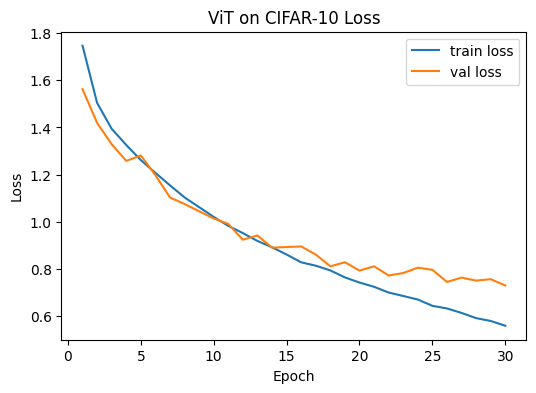

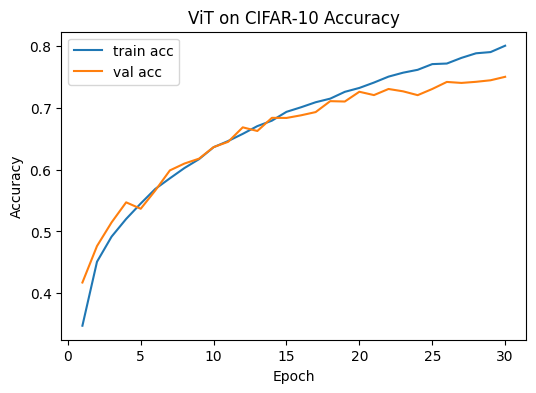

In [37]:
MODEL_NAME = "vit_tiny_cifar_30ep"
if TRAIN_VIT_CIFAR:
    # Training
    vit_cifar = ViTTiny(num_classes=len(cifar_class_names), embed_dim=192, depth=6, num_heads=3).to(device)

    vit_cifar, history, metrics, path = train_model(
        model=vit_cifar,
        train_loader=cifar_loaders["train"],
        val_loader=cifar_loaders["val"],
        test_loader=cifar_loaders["test"],
        epochs=30,
        lr=3e-4,
        device=device,
        save_folder_name=f"{MODEL_NAME}",
    )

    print("Saved to:", path)
    print("Final metrics:", metrics)
    plot_history(history, title="ViT on CIFAR-10")
else:
    print(device)
    ckpt_path = f"weights/project_3/{MODEL_NAME}/{MODEL_NAME}_model_weights.pth"
    ckpt = torch.load(ckpt_path, map_location=device)

    cifar_num_classes = len(cifar_class_names)
    vit_cifar = ViTTiny(num_classes=cifar_num_classes).to(device)
    vit_cifar.load_state_dict(ckpt["model_state_dict"])
    print("Loaded checkpoint keys:", ckpt.keys())
    if "metrics" in ckpt:
        print("Saved metrics:", ckpt["metrics"])
    history = ckpt["history"]
    plot_history(history, title="ViT on CIFAR-10")

##### Evaluate/Results

Test loss: 0.7317026058515421
Test acc : 0.7499001597444089
Confusion matrix shape: (10, 10)


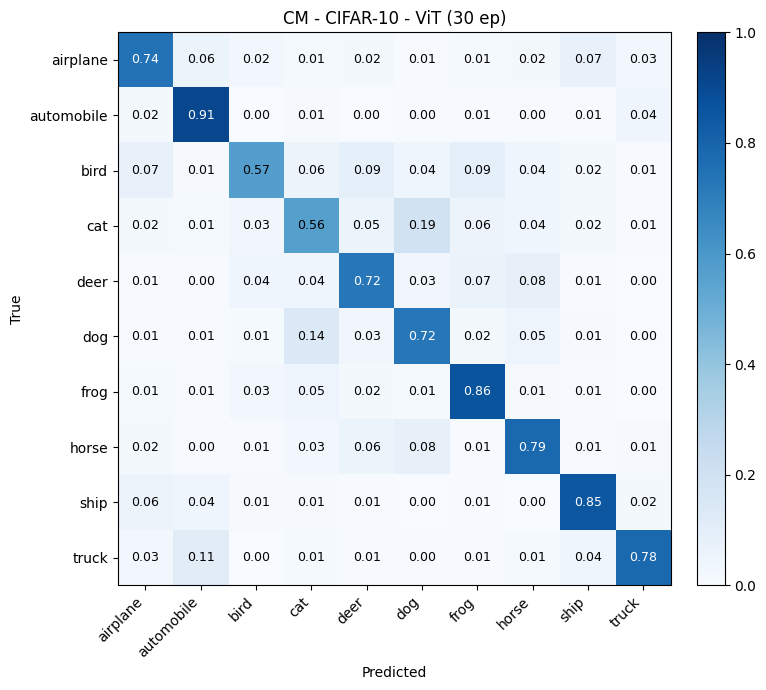

In [38]:
# Evaluate

criterion = nn.CrossEntropyLoss()

test_loss, test_acc, _, y_true, y_pred = evaluate(
    vit_cifar,
    cifar_loaders["test"],
    criterion,
    device,
    return_preds=True
)

cm = confusion_matrix(
    y_true, y_pred,
    labels=list(range(cifar_num_classes))
)

print("Test loss:", test_loss)
print("Test acc :", test_acc)

print("Confusion matrix shape:", cm.shape)  # should be (10, 10)
plot_confusion_matrix(cm,cifar_class_names,title="CM - CIFAR-10 - ViT (30 ep)")

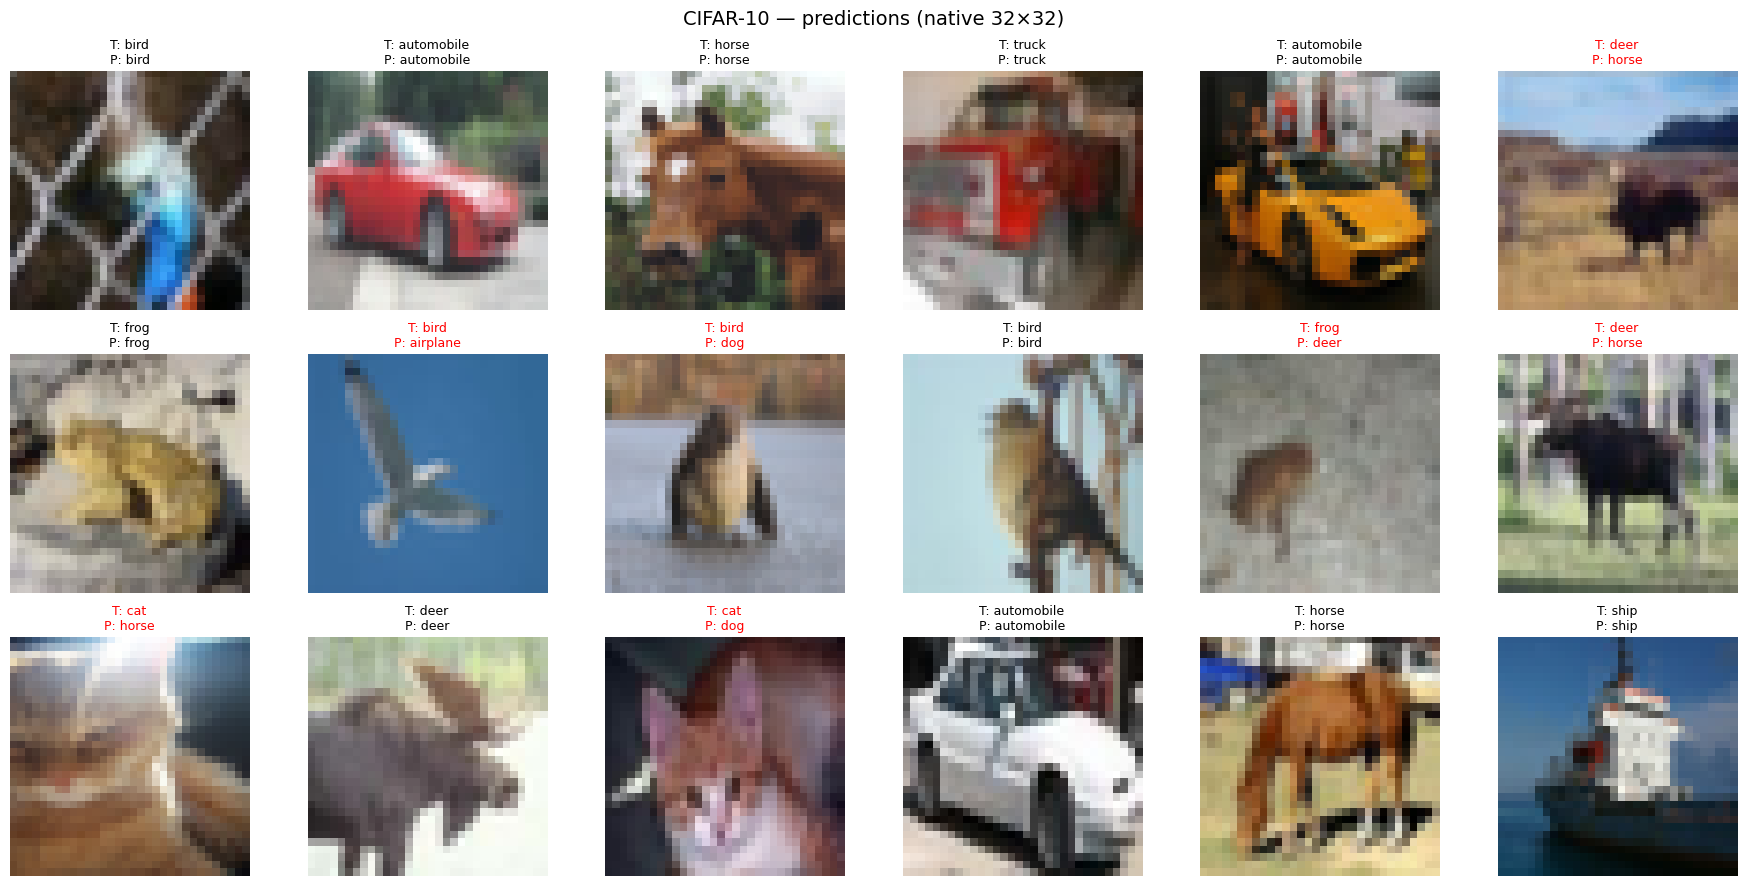

In [39]:
idxs = pick_indices(y_true, y_pred, n=18, only_errors=False, seed=0)
show_predictions_grid_viz(viz_cifar_test, idxs, y_true, y_pred, cifar_class_names,title="CIFAR-10 — predictions (native 32×32)")

In [40]:
top_confusions(y_true, y_pred, cifar_class_names, top_k=10)

Top 10 confusions (true -> pred : count):
cat -> dog : 193
dog -> cat : 138
truck -> automobile : 112
bird -> frog : 90
bird -> deer : 90
deer -> horse : 79
horse -> dog : 79
airplane -> ship : 73
bird -> airplane : 73
deer -> frog : 65


##### Analysis

| Dataset | Model | Criterion | Optimizer | Learning Rate | Epochs | Best Epoch | Best Val Acc | Final Val Acc | Final Test Acc | Final Val Macro-F1 | Final Test Macro-F1 |
|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|
| CIFAR-10 | Vision Transformers | CrossEntropyLoss | AdamW | 3e-4 | 30 | 30 | 0.75 | 0.75 | 0.749 | 0.747 | 0.748 |

---

| Dataset | Model | Total Training Time | Train Peak Mem. Bytes | Val Peak Mem. Bytes | Test Peak Mem. Bytes |
|-----|-----|-----|-----|-----|-----|
| CIFAR-10 | Vision Transformers | 1h12 |99.3 MB | 92.8 MB | 92.8 MB | 

**Losses/Metrics**
- The training is stable, the train loss decreases smoothly from 1.7 to 0.55, over 30 epochs.
- The training accuracy rises to 80%. The validation accuracy also rises and reaches 75% at epoch 25, but seems to start plateauing from epoch 25. Which can indicate a bit of overfitting.
- The algorithm reaches 75% accuracy on the test set and a macro-f1 of 74.8%, which means the performance is overall balanced across all classes.

**Predictions**
- The confusion matrix shows that the strongest classes are automobile (0.91), frog (0.86), ship (0.85), horse (0.79) and truck (0.78).
- Among the most confused classes we have 193 cats that were predicted as dogs, and 138 dogs that were predicted as cats. There are also 112 trucks predictied as automobiles (both are vehicules so this confusion is understandable). Overall, most errors are semantically close pairs, so the models seems to learn meaningful features but struggles with the "barriers" that allow to separate the classes more precisely.

**Short conclusion**
- This Vision Transformers trains cleanly on the CIFAR-10 dataset and reaches a 75% accuracy at 30 epochs. The remaining errors are mostly between visually similar classes.

### 3.3 - Vision Transformers - FOOD-101

##### Train

mps
Loaded checkpoint keys: dict_keys(['model_state_dict', 'history', 'metrics', 'config'])
Saved metrics: {'best_val_acc': 0.42404121459159166, 'best_epoch': 30, 'final_val_acc': 0.42404121459159166, 'final_val_macro_f1': 0.4180083771932412, 'final_test_acc': 0.47080696202531647, 'final_test_macro_f1': 0.46447914850851024, 'total_training_time_sec': 9920.158028750011, 'train_peak_mem_bytes': 109545984, 'val_peak_mem_bytes': 103037440, 'test_peak_mem_bytes': 93918208, 'device': 'mps', 'lr': 0.0003, 'epochs': 30}


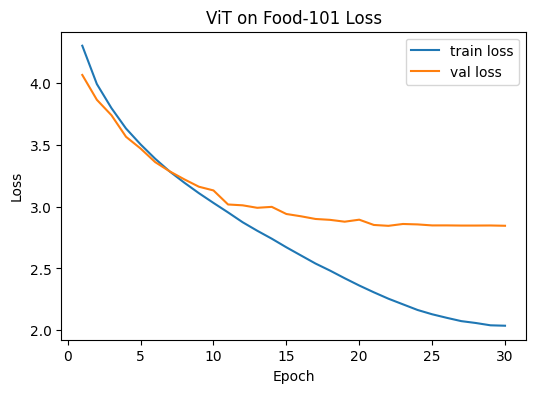

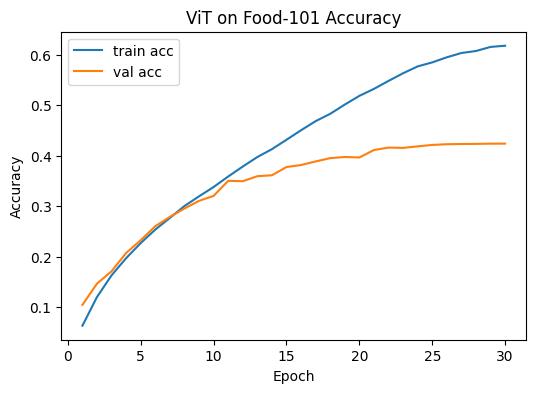

In [ ]:
EPOCHS = 30
MODEL_NAME = "vit_tiny_food_30ep" 
if TRAIN_VIT_FOOD:
    # Training
    vit_food = ViTTiny(num_classes=len(food_class_names), embed_dim=192, depth=6, num_heads=3).to(device)

    vit_food, history, metrics, path = train_model(
        model=vit_food,
        train_loader=food_loaders["train"],
        val_loader=food_loaders["val"],
        test_loader=food_loaders["test"],
        epochs=EPOCHS,
        lr=3e-4,
        device=device,
        save_folder_name=f"{MODEL_NAME}",
    )

    print("Saved to:", path)
    print("Final metrics:", metrics)
    plot_history(history, title="ViT on Food-101")
else:
    print(device)
    ckpt_path = f"weights/project_3/{MODEL_NAME}/{MODEL_NAME}_model_weights.pth"
    ckpt = torch.load(ckpt_path, map_location=device)

    vit_food = ViTTiny(num_classes=len(food_class_names)).to(device)
    vit_food.load_state_dict(ckpt["model_state_dict"])

    print("Loaded checkpoint keys:", ckpt.keys())
    history = ckpt.get("history", None)

    
    print("Saved metrics:", ckpt.get("metrics", {}))
    if history is not None:
        plot_history(history, title="ViT on Food-101")

##### Evaluate/Results

In [ ]:
# Evaluate

criterion = nn.CrossEntropyLoss()
#criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

test_loss, test_acc, _, y_true, y_pred = evaluate(
    vit_food,
    food_loaders["test"],
    criterion,
    device,
    return_preds=True
)

food_num_classes = len(food_class_names)
cm = confusion_matrix(
    y_true, y_pred,
    labels=list(range(food_num_classes))
)

print("Test loss:", test_loss)
print("Test acc :", test_acc)


Test loss: 2.631459474865394
Test acc : 0.47080696202531647


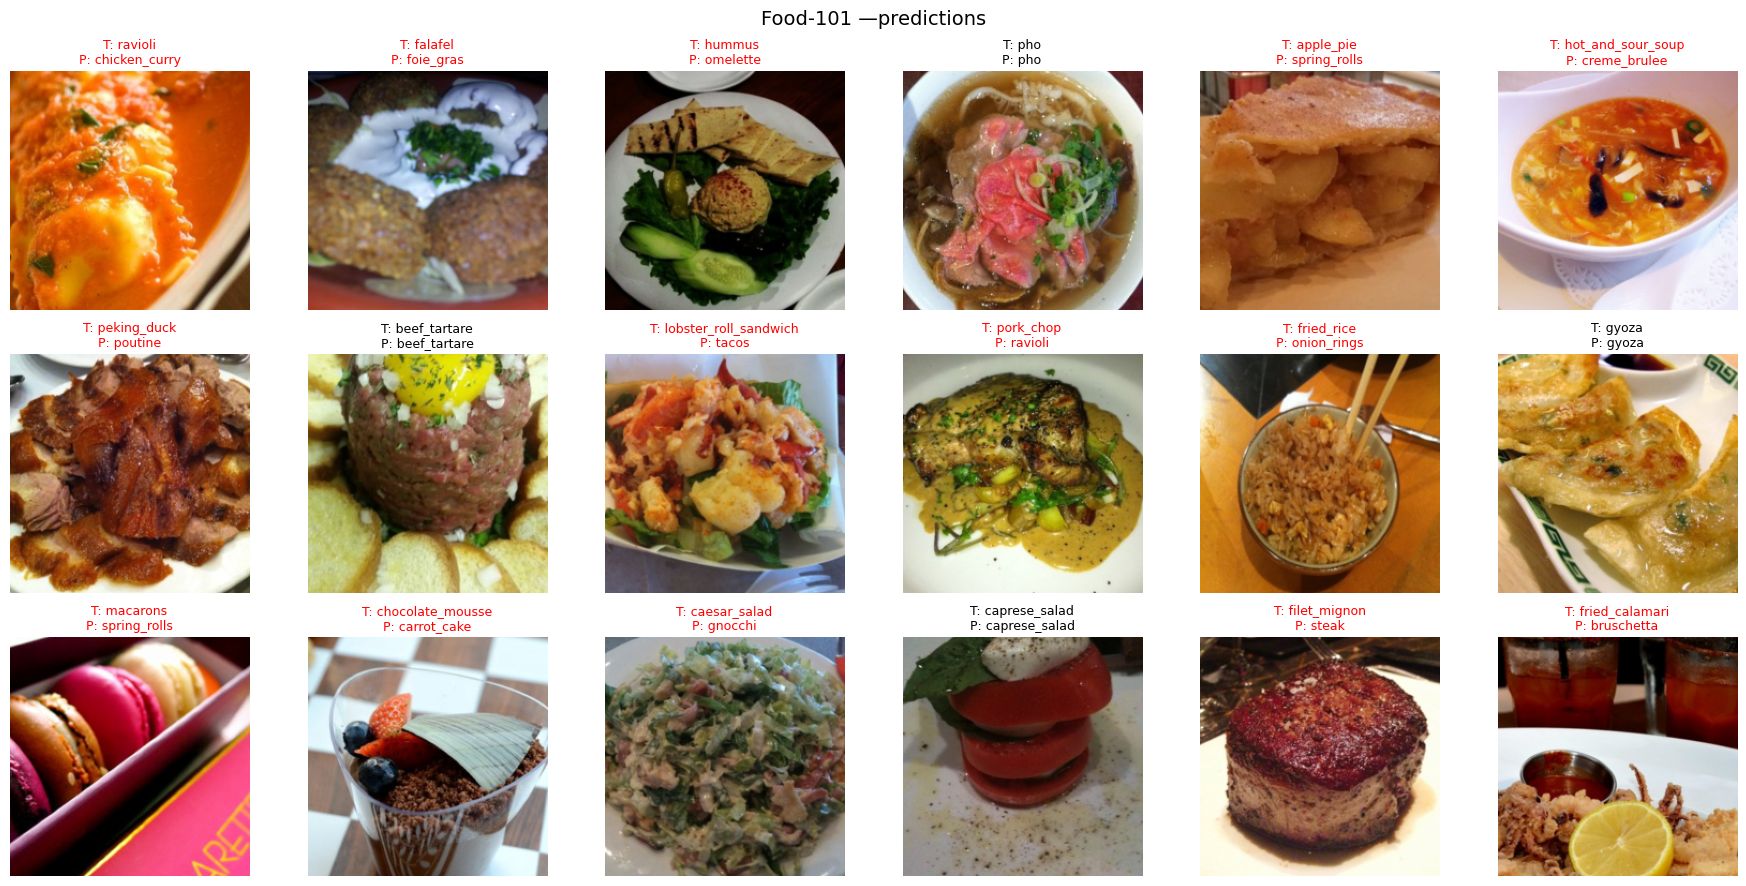

In [47]:
idxs = pick_indices(y_true, y_pred, n=18, only_errors=False, seed=0)
show_predictions_grid(test_food_split, idxs, y_true, y_pred, food_class_names,
                      mean=torch.tensor(IMAGENET_MEAN), std=torch.tensor(IMAGENET_STD),
                      title="Food-101 —predictions")

In [48]:
top_confusions(y_true, y_pred, food_class_names, top_k=15)

Top 15 confusions (true -> pred : count):
tuna_tartare -> beef_tartare : 38
steak -> filet_mignon : 35
panna_cotta -> cheesecake : 29
chocolate_mousse -> chocolate_cake : 29
french_fries -> onion_rings : 26
pulled_pork_sandwich -> hamburger : 25
caprese_salad -> beef_carpaccio : 25
onion_rings -> french_fries : 25
ravioli -> gnocchi : 25
clam_chowder -> lobster_bisque : 24
beef_tartare -> tuna_tartare : 23
pad_thai -> spaghetti_bolognese : 23
cannoli -> beignets : 23
cheesecake -> panna_cotta : 23
ravioli -> shrimp_and_grits : 22


##### Analysis

| Dataset | Model | Criterion | Optimizer | Learning Rate | Epochs | Best Epoch | Best Val Acc | Final Val Acc | Final Test Acc | Final Val Macro-F1 | Final Test Macro-F1 |
|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|
| FOOD-101 | Vision Transformers (v1) | CrossEntropyLoss | AdamW | 3e-4 | 30 | 25 | 0.398 | 0.398 | 0.442 | 0.393 | 0.437 |
| FOOD-101 | Vision Transformers (v2) | CrossEntropyLoss(label_smoothing) | AdamW | 3e-4 | 30 | 30 | 0.424| 0.424 | 0.471 | 0.418 | 0.465 |
| FOOD-101 | Vision Transformers (v3) | CrossEntropyLoss | AdamW (lr_scheduling) | 3e-4| 30 | 29 | 0.419 | 0.419 | 0.476 | 0.413 | 0.470 |

---

| Dataset | Model | Total Training Time | Train Peak Mem. Bytes | Val Peak Mem. Bytes | Test Peak Mem. Bytes |
|-----|-----|-----|-----|-----|-----|
| FOOD-101 | Vision Transformers (v1) | 2h44 | 109.5 MB | 103 MB | 93.9 MB |
| FOOD-101 | Vision Transformers (v2) | 2h45 | 109.5 MB | 103 MB | 93.9 MB | 
| FOOD-101 | Vision Transformers (v3) | 2h45 | 109.5 MB | 103 MB | 93.9 MB | 


**Losses/Metrics**
- The train loss decreases smoothly from 4.2 to 1.4, and the train accuracy rises up to 60% by epoch 30.
- But, the validation saturates early, decreases from 4 to 2.5 up to epoch 15 and then plateaus. After 15/20 epochs we observe clear overfitting as the gap between the two losses increases over time. After 25 epochs, the training does not improve anymore the validaiton metrics.

**Predictions**
- Our most confused features are similar plates :french_fries/onion_rings are both fried food, tuna_tartare/beef_tartare are both same looking raw plates, steak/filet_mignon are both cooked pieces of meat. So the confusions looks reasonable, the are mostly between similar classes.

**Short conclusion**
- Food-101 is a harder dataset to train on as there are 101 classes. With our small ViT design, the model seems to be learning only useful features but do not generalize as well as what we observed for CIFAR-10.
- The ViT reached 39.8% val accuracy and 44.2% test accuracy after 30 epochs.

### 3.4 - Conclusion on Vision Transformers

| Dataset | Model | Criterion | Optimizer | Learning Rate | Epochs | Best Epoch | Best Val Acc | Final Val Acc | Final Test Acc | Final Val Macro-F1 | Final Test Macro-F1 |
|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|
| CIFAR-10 | Vision Transformers | CrossEntropyLoss | AdamW | 3e-4 | 30 | 30 | 0.75 | 0.75 | 0.749 | 0.747 | 0.748 |
| FOOD-101 | Vision Transformers (v1) | CrossEntropyLoss | AdamW | 3e-4 | 30 | 25 | 0.398 | 0.398 | 0.442 | 0.393 | 0.437 |
| FOOD-101 | Vision Transformers (v2) | CrossEntropyLoss(label_smoothing) | AdamW | 3e-4 | 30 | 30 | 0.424| 0.424 | 0.471 | 0.418 | 0.465 |
| FOOD-101 | Vision Transformers (v3) | CrossEntropyLoss | AdamW (lr_scheduling) | 3e-4| 30 | 29 | 0.419 | 0.419 | 0.476 | 0.413 | 0.470 |


---

| Dataset | Model | Total Training Time | Train Peak Mem. Bytes | Val Peak Mem. Bytes | Test Peak Mem. Bytes |
|-----|-----|-----|-----|-----|-----|
| CIFAR-10 | Vision Transformers | 1h12 |99.3 MB | 92.8 MB | 92.8 MB | 
| FOOD-101 | Vision Transformers (v1) | 2h44 | 109.5 MB | 103 MB | 93.9 MB |
| FOOD-101 | Vision Transformers (v2) | 2h45 | 109.5 MB | 103 MB | 93.9 MB | 
| FOOD-101 | Vision Transformers (v3) | 2h45 | 109.5 MB | 103 MB | 93.9 MB | 

- Across both datasets, our ViT trained stably and learned some meaningful features.
- On CIFAR-10, the model reached 75% accuracy on the test set. So a lightweight ViT seems to perform relatively well on a 10-class dataset when trained on 30 epochs.
- On FOOD-101, the performanced dropped to 44% on the test accuracy. Training a ViT from scratch on a larger dataset is more challenging. The training curves shows overfitting after 15/20 epochs, which means that the model's regularization was not sufficient for FOOD-101. However, the mistakes made by the algorithm are mostly due to confusions between visually similar classes.
- Using label smoothing and a learning rate scheduler slightly improved generalization (approximately 47% test accuracy for both of these adjustments.)
- Using stronger augmentation, training longer and using pre-trained weights might improve the results on both datasets.

## 4 - Comparison

##### Results on CIFAR-10 vs Literature

Comparison with literature

##### Results on FOOD-101 vs Literature

## 5 - Conclusion

- Conclusion

---
---

### Brainstorming + Infos

**Models**
- Custom CNN
- ResNet-18
- ViT-Tiny/16 (patch size : 16, embed dim : 192, depth : 12, heads : 3) (smaller than ViT B-16)
- Swin-T (Swin Tiny)

**Datasets**
- CIFAR-10 : 60k images, 32x32, 10 classes (50k train / 10k test)
- Food-101 : 101k images, 101 classes (750 train + 250 test per class, noisy training set)
- Important : For ImageNet-pretrained fine-tuning: resize/crop inputs to 224×224 for ResNet/ViT/Swin (and ideally also for the custom CNN for fair time/memory comparison)



**Training settings**
- Train from scratch on CIFAR-10 (4 from-scratch trainings)
- Train from scratch on Food-101 (4 from-scratch trainings)

| Dataset | Type | Custom CNN | ResNet-18 | ViT-Tiny | Swin-T |
|-----|-----|-----|-----|-----|-----|
| CIFAR-10 | From Scratch | 224 | 224 | 224 | 224 |
| Food-101 | From Scratch| 224 | 224 | 224 | 224 |

**Calculated metrics**
- best_val_acc : highest validation accuracy reached during training
- final_val_acc : validation accuracy after training fineshed, evaluated using the best weights
- final_test_acc : accuracy on the test set, using the best validation model
- final_val_macro_f1 : macro_f1 is the average of per-class f1_scores (each class contributes equally), final_val_marcro_f1 is the macro_f1 on the val set using the best model
- final_test_macro_f1 : macro_f1 on the test set using the best model
- total_training_time_sec : total training time in sec
- traink_peak_mem_bytes : The maximum torch.mps.current_allocated_memory() observed during training batches
- val_peak_mem_bytes : peak allocated memory observed during validation
- test_peak_mem_bytes : same for the test loop
